In [1]:
### IMPORTS ###
import sys
sys.path.append('../')

import autolib
import fom
import Optimisation.opt as opt
import pathlib
#from pathlib import PosixPath
#user_home_path = PosixPath('~/')
#user_home_path_full = user_home_path.expanduser()


final_speed = 20.
num_cores = 200
maxtime = 1440
runID = "Fasympmonochrome_fixgaussian20_50GW_nG30"
#runID = "Fasymp20_fixgaussian20_50GW" # _nG30"

student = "JadonsSolution"  # Change this to your name or preferred folder name

filepath = r"C:\\Users\\rosew\\relativistic-lightsail-dynamics\\Optimisation"
current_dir = pathlib.Path(filepath).resolve(strict=True).parent
fname_preamble = current_dir / "Combining" / "Data" / student

# fname_preamble = common_path / custom_folder_path

# import pathlib
# fname_preamble = pathlib.Path("./Data")

pkl_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}'
txt_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}_curated.txt'

maxima_and_maximisers_sorted, opt_gratings_sorted, _ = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=0)

Total function evaluations: 7171191
Average function evaluations per core: 35855


In [2]:
def print_grating_params(grating):
    print(f"grating_pitch   = {grating.params[0]}")
    print(f"grating_depth   = {grating.params[1]}")
    print(f"box1_width      = {grating.params[2]}")
    print(f"box2_width      = {grating.params[3]}")
    print(f"box_centre_dist = {grating.params[4]}")
    print(f"box1_eps        = {grating.params[5]}")
    print(f"box2_eps        = {grating.params[6]}")
    print(f"gaussian_width  = {grating.params[7]}")
    print(f"substrate_depth = {grating.params[8]}")
    print(f"substrate_eps   = {grating.params[9]}")

In [3]:
import numpy as np
import os
os.environ["OMP_NUM_THREADS"] = "1" 
os.environ["OPENBLAS_NUM_THREADS"] = "1" 
os.environ["MKL_NUM_THREADS"] = "1" 
os.environ["VECLIB_MAXIMUM_THREADS"] = "1" 
os.environ["NUMEXPR_NUM_THREADS"] = "1" 

import parameters
from parameters import D1_ND

from twobox import TwoBox

I0, L, m, c = parameters.Parameters()
optimum_number = 4

# wavelength_range = [1,1/D1_ND([final_speed/100,0])]
wavelength_range = [0.99999,1.0000004]
bandwidth = wavelength_range[1] - wavelength_range[0]
relative_bandwidth = bandwidth / wavelength_range[0]
wavelength_range = [0.99999 - 10.*relative_bandwidth, 1.0000004 + 10.*relative_bandwidth]
print(wavelength_range)
_, _, opt_grating = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=optimum_number)
optimisation_RCWA_engine = opt_grating.RCWA_engine
print(optimisation_RCWA_engine)

# Test optimum FOM convergence by rebuilding the grating with higher fidelity
match optimisation_RCWA_engine:
    case "GRCWA":  # GRCWA opt params are saved as autograd ArrayBoxes, have to get values manually
        opt_params = [p._value for p in opt_grating.all_params]
    case _:
        opt_params = opt_grating.all_params
print(opt_params)
print(opt_grating.params)
grating = TwoBox(*opt_params, wavelength=1., angle=0., Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)
grating_converged = TwoBox(*opt_params, wavelength=1., angle=0., Nx=1000, nG=100, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)    

print(fom.multifom(grating, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
# print(fom.multifom(grating_converged, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
print(f"grating_pitch   = {grating.params[0]}")
print(f"grating_depth   = {grating.params[1]}")
print(f"box1_width      = {grating.params[2]}")
print(f"box2_width      = {grating.params[3]}")
print(f"box_centre_dist = {grating.params[4]}")
print(f"box1_eps        = {grating.params[5]}")
print(f"box2_eps        = {grating.params[6]}")
print(f"gaussian_width  = {grating.params[7]}")
print(f"substrate_depth = {grating.params[8]}")
print(f"substrate_eps   = {grating.params[9]}")
print(f"\nFoM recorded:     {maxima_and_maximisers_sorted[optimum_number][0]}")

[0.99988599895999, 1.00010440104001]
Total function evaluations: 7171191
Average function evaluations per core: 35855
TORCWA
[tensor(1.5890, dtype=torch.float64), tensor(0.6815, dtype=torch.float64), tensor(1.1635, dtype=torch.float64), tensor(1.2270, dtype=torch.float64), tensor(0.4843, dtype=torch.float64), tensor(12.2500, dtype=torch.float64), tensor(8.4398, dtype=torch.float64), tensor(20., dtype=torch.float64), tensor(1.8405, dtype=torch.float64), tensor(7.7248, dtype=torch.float64)]
[tensor(1.5890, dtype=torch.float64), tensor(0.6815, dtype=torch.float64), tensor(1.1635, dtype=torch.float64), tensor(1.2270, dtype=torch.float64), tensor(0.4843, dtype=torch.float64), tensor(12.2500, dtype=torch.float64), tensor(8.4398, dtype=torch.float64), tensor(1.8405, dtype=torch.float64), tensor(7.7248, dtype=torch.float64)]


c:\Users\rosew\AppData\Local\Programs\Python\Python312\Lib\site-packages\torcwa\rcwa.py:62: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  self.L = torch.as_tensor(L,dtype=self._dtype,device=self._device)


0.014213230597554142
grating_pitch   = 1.588999104221404
grating_depth   = 0.6814547486670015
box1_width      = 1.1635183838602672
box2_width      = 1.2269988733783472
box_centre_dist = 0.4843187147417837
box1_eps        = 12.249968465054828
box2_eps        = 8.43981679664437
gaussian_width  = 20.0
substrate_depth = 1.8404998380763957
substrate_eps   = 7.724841176163067

FoM recorded:     0.014213230598221122


In [4]:
scaled = 1.000025 # Scale to new wavelength
scaled_opt_params = opt_params.copy()

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled * scaled_opt_params[p]
    
scaled_grating = TwoBox(*scaled_opt_params, wavelength=scaled, angle=0., 
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

actual_fom = fom.multifom(scaled_grating, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print_grating_params(scaled_grating)
print(f"\nFoM at scaled wavelength: {actual_fom}")

grating_pitch   = 1.5890388291990094
grating_depth   = 0.6814717850357181
box1_width      = 1.1635474718198635
box2_width      = 1.2270295483501816
box_centre_dist = 0.48433082270965216
box1_eps        = 12.249968465054828
box2_eps        = 8.43981679664437
gaussian_width  = 20.0005
substrate_depth = 1.8405458505723475
substrate_eps   = 7.724841176163067

FoM at scaled wavelength: 0.014211517059641113


In [5]:
calc_foms = []
scales = np.logspace(np.log10(0.01), np.log10(2), 100)
for scaled in scales:
    scaled_opt_params = opt_params.copy()

    param_ls = [0, 1, 2, 3, 4, 7, 8]
    for p in param_ls:
        scaled_opt_params[p] = scaled * scaled_opt_params[p]
        
    scaled_grating = TwoBox(*scaled_opt_params, wavelength=scaled, angle=0., 
                            Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                            RCWA_engine=opt_grating.RCWA_engine, 
                            torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

    recorded_fom = fom.multifom(scaled_grating, monofom=fom.monofom_asymp,
                                final_speed=final_speed, goal=0.1, return_grad=False)

    #print_grating_params(scaled_grating)
    print(f"FoM at scaled wavelength {scaled}: {recorded_fom}")
    calc_foms.append(recorded_fom)

FoM at scaled wavelength 0.01: -305.888768005491
FoM at scaled wavelength 0.01054976358041775: -303.5826596177366
FoM at scaled wavelength 0.011129751160270877: -301.0428749434817
FoM at scaled wavelength 0.011741624344973797: -298.24954450714176
FoM at scaled wavelength 0.012387136088955098: -295.18199769046
FoM at scaled wavelength 0.013068135717693687: -291.8189612852468
FoM at scaled wavelength 0.013786574225848126: -288.1388259688763
FoM at scaled wavelength 0.01454450986665786: -284.1199895766255
FoM at scaled wavelength 0.015344114048629382: -279.7412859230197
FoM at scaled wavelength 0.016187677556400663: -274.98250434121843
FoM at scaled wavelength 0.017077617113606152: -269.8250032740369
FoM at scaled wavelength 0.01801648230654411: -264.25241324641877
FoM at scaled wavelength 0.019006962888481985: -258.2514215973263
FoM at scaled wavelength 0.020051896485525914: -251.81261605429725
FoM at scaled wavelength 0.021154276726130787: -244.93136183039687
FoM at scaled wavelength 0.

In [7]:
import matplotlib.pyplot as plt
plt.clf()
plt.semilogx(scales, calc_foms, label='Calculated FoM at scaled wavelength')

plt.plot(scales, np.zeros_like(scales)+actual_fom, 'k--', label='Original FoM of Jadon Solution')
plt.xlabel('Scaled wavelength')
plt.ylabel('Figure of Merit (FoM)')
plt.title('FoM vs Scaled Wavelength for Optimised Grating')
plt.legend()

NameError: name 'scales' is not defined

<Figure size 1500x750 with 0 Axes>

In [5]:
scaled = scales[np.argmax(calc_foms)]

scaled_opt_params = opt_params.copy()

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled * scaled_opt_params[p]
    
scaled_grating = TwoBox(*scaled_opt_params, wavelength=scaled, angle=0., 
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

recorded_fom = fom.multifom(scaled_grating, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print_grating_params(scaled_grating)
print(f"FoM at scaled wavelength {scaled}: {recorded_fom}")

NameError: name 'scales' is not defined

In [8]:
stiffnesses_original = fom.force_coeff(grating,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix
stiffnesses_scaled = fom.force_coeff(scaled_grating,I0,m,c,grad_method="finite",out="mat",normalise=False)

J_original = grating.npa.concatenate((grating.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses_original))
J_scaled = scaled_grating.npa.concatenate((scaled_grating.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses_scaled))


eigReal_o, eigImag_o = fom.Eigs(grating,I0,m,c,grad_method="finite",
                            return_vec = False, normalise=False, use_perturbed=False) # to get eigenvalues

eigReal_s, eigImag_s = fom.Eigs(scaled_grating,I0,m,c,grad_method="finite",
                            return_vec = False, normalise=False, use_perturbed=False) # to get eigenvalues

# i think just replace grating with the grating needed (scaled or original)

In [16]:
avg_J = 0.5 * (J_original + J_scaled)

In [26]:
import torch
eigs_avgJ = torch.linalg.eigvals(avg_J).real
print(eigs_avgJ)

tensor([-0.5452, -0.5452, -0.0074, -0.0074], dtype=torch.float64,
       grad_fn=<SelectBackward0>)


In [7]:
avg_of_eigs_real = 0.5 * (eigReal_o + eigReal_s)

In [8]:
print(avg_of_eigs_real)

tensor([-0.5452, -0.5452, -0.0074, -0.0074], dtype=torch.float64,
       grad_fn=<MulBackward0>)


In [29]:
scaled = 1.000025 # Scale to new wavelength
scaled_opt_params = opt_params.copy()

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled * scaled_opt_params[p]
    
scaled_grating_NOT_wavelength = TwoBox(*scaled_opt_params, wavelength=1., angle=0., 
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

actual_fom_NOT_scaling_wavelength = fom.multifom(scaled_grating_NOT_wavelength, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print_grating_params(scaled_grating_NOT_wavelength)
print(f"\nFoM at scaled wavelength: {actual_fom}")
print(f"\nFoM at unscaled wavelength: {actual_fom_NOT_scaling_wavelength}")

grating_pitch   = 1.5890388291990094
grating_depth   = 0.6814717850357181
box1_width      = 1.1635474718198635
box2_width      = 1.2270295483501816
box_centre_dist = 0.48433082270965216
box1_eps        = 12.249968465054828
box2_eps        = 8.43981679664437
gaussian_width  = 20.0005
substrate_depth = 1.8405458505723475
substrate_eps   = 7.724841176163067

FoM at scaled wavelength: 0.014211517059641113

FoM at unscaled wavelength: -3.4911344847983337


In [14]:
scaled2 = 1.05 # Scale to new wavelength
scaled_opt_params = opt_params.copy()

#With scaled wavelength still

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled2 * scaled_opt_params[p]
    
scaled_grating2 = TwoBox(*scaled_opt_params, wavelength=scaled2, angle=0., 
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

actual_fom2 = fom.multifom(scaled_grating2, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print_grating_params(scaled_grating2)
print(f"\nFoM at scaled wavelength: {actual_fom2}")

grating_pitch   = 1.6684490594324743
grating_depth   = 0.7155274861003517
box1_width      = 1.2216943030532805
box2_width      = 1.2883488170472646
box_centre_dist = 0.5085346504788729
box1_eps        = 12.249968465054828
box2_eps        = 8.43981679664437
gaussian_width  = 21.0
substrate_depth = 1.9325248299802156
substrate_eps   = 7.724841176163067

FoM at scaled wavelength: 0.011230349643794537


Checking the Qprs are the same!!

In [16]:
h_angle = 10**(-6.5)
h_wavelength = 10**(-6.5)
Q1R, Q2R, dQ1ddeltaR, dQ2ddeltaR, dQ1dlambdaR, dQ2dlambdaR = grating.return_Qs(h_angle, h_wavelength)
Q1L = Q1R                ; Q2L = -Q2R;   
dQ1ddeltaL  = -dQ1ddeltaR; dQ2ddeltaL  = dQ2ddeltaR
dQ1dlambdaL = dQ1dlambdaR; dQ2dlambdaL = -dQ2dlambdaR        
Qprs = [Q1R, Q1L, Q2R, Q2L, 
        dQ1ddeltaR, dQ1ddeltaL, dQ2ddeltaR, dQ2ddeltaL, 
        dQ1dlambdaR, dQ1dlambdaL, dQ2dlambdaR, dQ2dlambdaL]
print(Qprs)

[tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(0.0538, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(-0.0538, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-3.4092, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(3.4092, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-9471.2824, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-9471.2824, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(3296.7695, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-3296.7695, dtype=torch.float64, grad_fn=<NegBackward0>)]


In [17]:
h_angle = 10**(-6.5)
h_wavelength = 10**(-6.5)
Q1R, Q2R, dQ1ddeltaR, dQ2ddeltaR, dQ1dlambdaR, dQ2dlambdaR = scaled_grating.return_Qs(h_angle, h_wavelength)
Q1L = Q1R                ; Q2L = -Q2R;   
dQ1ddeltaL  = -dQ1ddeltaR; dQ2ddeltaL  = dQ2ddeltaR
dQ1dlambdaL = dQ1dlambdaR; dQ2dlambdaL = -dQ2dlambdaR        
Qprs_scaled = [Q1R, Q1L, Q2R, Q2L, 
        dQ1ddeltaR, dQ1ddeltaL, dQ2ddeltaR, dQ2ddeltaL, 
        dQ1dlambdaR, dQ1dlambdaL, dQ2dlambdaR, dQ2dlambdaL]

print(Qprs_scaled)

[tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(0.0538, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(-0.0538, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-3.4092, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(3.4092, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-9471.0456, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-9471.0456, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(3296.6870, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-3296.6870, dtype=torch.float64, grad_fn=<NegBackward0>)]


In [19]:
h_angle = 10**(-6.5)
h_wavelength = 10**(-6.5)
Q1R, Q2R, dQ1ddeltaR, dQ2ddeltaR, dQ1dlambdaR, dQ2dlambdaR = scaled_grating2.return_Qs(h_angle, h_wavelength)
Q1L = Q1R                ; Q2L = -Q2R;   
dQ1ddeltaL  = -dQ1ddeltaR; dQ2ddeltaL  = dQ2ddeltaR
dQ1dlambdaL = dQ1dlambdaR; dQ2dlambdaL = -dQ2dlambdaR        
Qprs_scaled2 = [Q1R, Q1L, Q2R, Q2L, 
        dQ1ddeltaR, dQ1ddeltaL, dQ2ddeltaR, dQ2ddeltaL, 
        dQ1dlambdaR, dQ1dlambdaL, dQ2dlambdaR, dQ2dlambdaL]


print(Qprs_scaled2)

[tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(0.0538, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(-0.0538, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-3.4092, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(3.4092, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-9020.2144, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-9020.2144, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(3139.7220, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-3139.7220, dtype=torch.float64, grad_fn=<NegBackward0>)]


In [20]:
scaled3 = 0.05 # Scale to new wavelength
scaled_opt_params = opt_params.copy()

#With scaled wavelength still

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled3 * scaled_opt_params[p]
    
scaled_grating3 = TwoBox(*scaled_opt_params, wavelength=scaled3, angle=0., 
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

actual_fom3 = fom.multifom(scaled_grating3, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print_grating_params(scaled_grating3)
print(f"\nFoM at scaled wavelength: {actual_fom3}")

grating_pitch   = 0.0794499552110702
grating_depth   = 0.03407273743335008
box1_width      = 0.05817591919301336
box2_width      = 0.06134994366891736
box_centre_dist = 0.024215935737089186
box1_eps        = 12.249968465054828
box2_eps        = 8.43981679664437
gaussian_width  = 1.0
substrate_depth = 0.0920249919038198
substrate_eps   = 7.724841176163067

FoM at scaled wavelength: -95.81663836479791


In [36]:
h_angle = 10**(-6.5)
h_wavelength = 10**(-6.5)
Q1R, Q2R, dQ1ddeltaR, dQ2ddeltaR, dQ1dlambdaR, dQ2dlambdaR = scaled_grating3.return_Qs(h_angle, h_wavelength)
Q1L = Q1R                ; Q2L = -Q2R;   
dQ1ddeltaL  = -dQ1ddeltaR; dQ2ddeltaL  = dQ2ddeltaR
dQ1dlambdaL = dQ1dlambdaR; dQ2dlambdaL = -dQ2dlambdaR        
Qprs_scaled3 = [Q1R, Q1L, Q2R, Q2L, 
        dQ1ddeltaR, dQ1ddeltaL, dQ2ddeltaR, dQ2ddeltaL, 
        dQ1dlambdaR, dQ1dlambdaL, dQ2dlambdaR, dQ2dlambdaL]


print(Qprs_scaled3)
Qprs_scaled3 = np.array([x.item() for x in Qprs_scaled3])
Qprs = np.array([x.item() for x in Qprs])
Qprs_scaled3 - Qprs

[tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(0.0538, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(-0.0538, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-3.4092, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(3.4092, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-193329.4532, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-193329.4532, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(71271.9432, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-71271.9432, dtype=torch.float64, grad_fn=<NegBackward0>)]


array([ 7.90634225e-12,  7.90634225e-12, -2.51695192e-12,  2.51695192e-12,
       -7.70136430e-06,  7.70136430e-06,  4.26643066e-07,  4.26643066e-07,
       -1.83858171e+05, -1.83858171e+05,  6.79751737e+04, -6.79751737e+04])

In [22]:
scaled4 = 0.13 # Scale to new wavelength
scaled_opt_params = opt_params.copy()

#With scaled wavelength still

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled3 * scaled_opt_params[p]
    
scaled_grating4 = TwoBox(*scaled_opt_params, wavelength=scaled4, angle=0., 
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

actual_fom4 = fom.multifom(scaled_grating4, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print_grating_params(scaled_grating4)
print(f"\nFoM at scaled wavelength: {actual_fom4}")

grating_pitch   = 0.0794499552110702
grating_depth   = 0.03407273743335008
box1_width      = 0.05817591919301336
box2_width      = 0.06134994366891736
box_centre_dist = 0.024215935737089186
box1_eps        = 12.249968465054828
box2_eps        = 8.43981679664437
gaussian_width  = 1.0
substrate_depth = 0.0920249919038198
substrate_eps   = 7.724841176163067

FoM at scaled wavelength: -2529.3819540409327


In [34]:
h_angle = 10**(-6.5)
h_wavelength = 10**(-6.5)
Q1R, Q2R, dQ1ddeltaR, dQ2ddeltaR, dQ1dlambdaR, dQ2dlambdaR = scaled_grating4.return_Qs(h_angle, h_wavelength)
Q1L = Q1R                ; Q2L = -Q2R;   
dQ1ddeltaL  = -dQ1ddeltaR; dQ2ddeltaL  = dQ2ddeltaR
dQ1dlambdaL = dQ1dlambdaR; dQ2dlambdaL = -dQ2dlambdaR        
Qprs_scaled4 = [Q1R, Q1L, Q2R, Q2L, 
        dQ1ddeltaR, dQ1ddeltaL, dQ2ddeltaR, dQ2ddeltaL, 
        dQ1dlambdaR, dQ1dlambdaL, dQ2dlambdaR, dQ2dlambdaL]


print(Qprs_scaled4)

Qprs_scaled4 = np.array([x.item() for x in Qprs_scaled4])
Qprs = np.array([x.item() for x in Qprs])
print(Qprs_scaled4)
diff = Qprs_scaled4 - Qprs
print(np.abs(diff/Qprs))

[tensor(1.8714, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(1.8714, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(-0., dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(0., dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-2.3523e-08, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(2.3523e-08, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-1.8714, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-1.8714, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-72.1802, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-72.1802, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(0., dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-0., dtype=torch.float64, grad_fn=<NegBackward0>)]
[ 1.87144352e+00  1.87144352e+00 -0.00000000e+00  0.00000000e+00
 -2.35225842e-08  2.35225842e-08 -1.87144352e+00 -1.87144352e+00
 -7.21801854e+01 -7.21801854e+01  0.00000000e+00 -0.00000000e+00]
[ 0.16868091  0.16868091  1.          1.          0.99999999 

In [34]:
####################### USE THIS ONE ########################################################
#GRAD METHOD 

calc_foms = []
scales = np.logspace(np.log10(0.01), np.log10(2), 100)

#original Qprs (unscaled)

Q1R, Q2R, dQ1ddeltaR, dQ2ddeltaR, dQ1dlambdaR, dQ2dlambdaR = grating.return_Qs_auto(return_Q=True)
Q1L = Q1R                ; Q2L = -Q2R;   
dQ1ddeltaL  = -dQ1ddeltaR; dQ2ddeltaL  = dQ2ddeltaR
dQ1dlambdaL = dQ1dlambdaR; dQ2dlambdaL = -dQ2dlambdaR        
Qprs = [Q1R, Q1L, Q2R, Q2L, 
        dQ1ddeltaR, dQ1ddeltaL, dQ2ddeltaR, dQ2ddeltaL, 
        dQ1dlambdaR, dQ1dlambdaL, dQ2dlambdaR, dQ2dlambdaL]

Qprs = np.array([x.item() for x in Qprs])
efficiencies_t = tuple(grating.return_Qs_auto(return_Q=True))
efficiencies = np.array([x.detach().cpu().numpy() for x in efficiencies_t])

DIFF_ARRAY_G = []
DIFF_EFFICIENCIES_G = []

for scaled in scales:
    scaled_opt_params = opt_params.copy()

    param_ls = [0, 1, 2, 3, 4, 7, 8]
    for p in param_ls:
        scaled_opt_params[p] = scaled * scaled_opt_params[p]
        
    scaled_grating = TwoBox(*scaled_opt_params, wavelength=scaled, angle=0., 
                            Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                            RCWA_engine=opt_grating.RCWA_engine, 
                            torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

    recorded_fom = fom.multifom(scaled_grating, monofom=fom.monofom_asymp,
                                final_speed=final_speed, goal=0.1, return_grad=False)
    

    #Q1R_s, Q2R_s, dQ1ddeltaR_s, dQ2ddeltaR_s, dQ1dlambdaR_s, dQ2dlambdaR_s = scaled_grating.return_Qs_auto(h_angle, h_wavelength)
    Q1R_s, Q2R_s, dQ1ddeltaR_s, dQ2ddeltaR_s, dQ1dlambdaR_s, dQ2dlambdaR_s = scaled_grating.return_Qs_auto(return_Q=True)
    Q1L_s = Q1R_s                ; Q2L_s = -Q2R_s;   
    dQ1ddeltaL_s  = -dQ1ddeltaR_s; dQ2ddeltaL_s  = dQ2ddeltaR_s
    dQ1dlambdaL_s = dQ1dlambdaR_s; dQ2dlambdaL_s = -dQ2dlambdaR_s    
    Qprs_scaled = [Q1R_s, Q1L_s, Q2R_s, Q2L_s, 
            dQ1ddeltaR_s, dQ1ddeltaL_s, dQ2ddeltaR_s, dQ2ddeltaL_s, 
            dQ1dlambdaR_s, dQ1dlambdaL_s, dQ2dlambdaR_s, dQ2dlambdaL_s]
    
    Qprs_scaled = np.array([x.item() for x in Qprs_scaled])
    efficiencies_s = tuple(scaled_grating.return_Qs_auto(return_Q=True))
    efficiencies_scaled = np.array([x.detach().cpu().numpy() for x in efficiencies_s])

    #print_grating_params(scaled_grating)
    print(f"FoM at scaled wavelength {scaled}: {recorded_fom}")
    calc_foms.append(recorded_fom)

    Qprs_mag_diff = np.abs((Qprs - Qprs_scaled) / Qprs)
    efficiences_mag_diff = np.abs((efficiencies - efficiencies_scaled) / efficiencies)
    DIFF_ARRAY_G.append(Qprs_mag_diff)
    DIFF_EFFICIENCIES_G.append(efficiences_mag_diff)

    #print(Qprs_mag_diff)
    #print(Qprs_scaled)
    #print(Qprs)




FoM at scaled wavelength 0.01: -305.888768005491
FoM at scaled wavelength 0.01054976358041775: -303.5826596177366
FoM at scaled wavelength 0.011129751160270877: -301.0428749434817
FoM at scaled wavelength 0.011741624344973797: -298.24954450714176
FoM at scaled wavelength 0.012387136088955098: -295.18199769046
FoM at scaled wavelength 0.013068135717693687: -291.8189612852468
FoM at scaled wavelength 0.013786574225848126: -288.1388259688763
FoM at scaled wavelength 0.01454450986665786: -284.1199895766255
FoM at scaled wavelength 0.015344114048629382: -279.7412859230197
FoM at scaled wavelength 0.016187677556400663: -274.98250434121843
FoM at scaled wavelength 0.017077617113606152: -269.8250032740369
FoM at scaled wavelength 0.01801648230654411: -264.25241324641877
FoM at scaled wavelength 0.019006962888481985: -258.2514215973263
FoM at scaled wavelength 0.020051896485525914: -251.81261605429725
FoM at scaled wavelength 0.021154276726130787: -244.93136183039687
FoM at scaled wavelength 0.

In [35]:
Q1R_g = []
Q1L_g = []
Q2R_g = []
Q2L_g = []
dQ1ddeltaR_g = [] 
dQ1ddeltaL_g = []
dQ2ddeltaR_g = []
dQ2ddeltaL_g = [] 
dQ1dlambdaR_g = [] 
dQ1dlambdaL_g = []
dQ2dlambdaR_g = []
dQ2dlambdaL_g = []

for i in range(0,len(scales)):

    Qprs = DIFF_ARRAY_G[i]
    Q1R_s = DIFF_ARRAY_G[i][0]
    Q1L_s = DIFF_ARRAY_G[i][1]
    Q2R_s = DIFF_ARRAY_G[i][2]
    Q2L_s = DIFF_ARRAY_G[i][3]
    dQ1ddeltaR_s = DIFF_ARRAY_G[i][4]
    dQ1ddeltaL_s = DIFF_ARRAY_G[i][5]
    dQ2ddeltaR_s = DIFF_ARRAY_G[i][6]
    dQ2ddeltaL_s = DIFF_ARRAY_G[i][7]
    dQ1dlambdaR_s = DIFF_ARRAY_G[i][8]
    dQ1dlambdaL_s = DIFF_ARRAY_G[i][9]
    dQ2dlambdaR_s = DIFF_ARRAY_G[i][10]
    dQ2dlambdaL_s = DIFF_ARRAY_G[i][11]

    Q1R_g.append(Q1R_s)
    Q1L_g.append(Q1L_s)
    Q2R_g.append(Q2R_s)
    Q2L_g.append(Q2L_s)
    dQ1ddeltaR_g.append(dQ1ddeltaR_s)
    dQ1ddeltaL_g.append(dQ1ddeltaL_s)
    dQ2ddeltaR_g.append(dQ2ddeltaR_s)
    dQ2ddeltaL_g.append(dQ2ddeltaL_s)
    dQ1dlambdaR_g.append(dQ1dlambdaR_s)
    dQ1dlambdaL_g.append(dQ1dlambdaL_s)
    dQ2dlambdaR_g.append(dQ2dlambdaR_s)
    dQ2dlambdaL_g.append(dQ2dlambdaL_s)


C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1867163100.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,0].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1867163100.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,1].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1867163100.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,2].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1867163100.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with

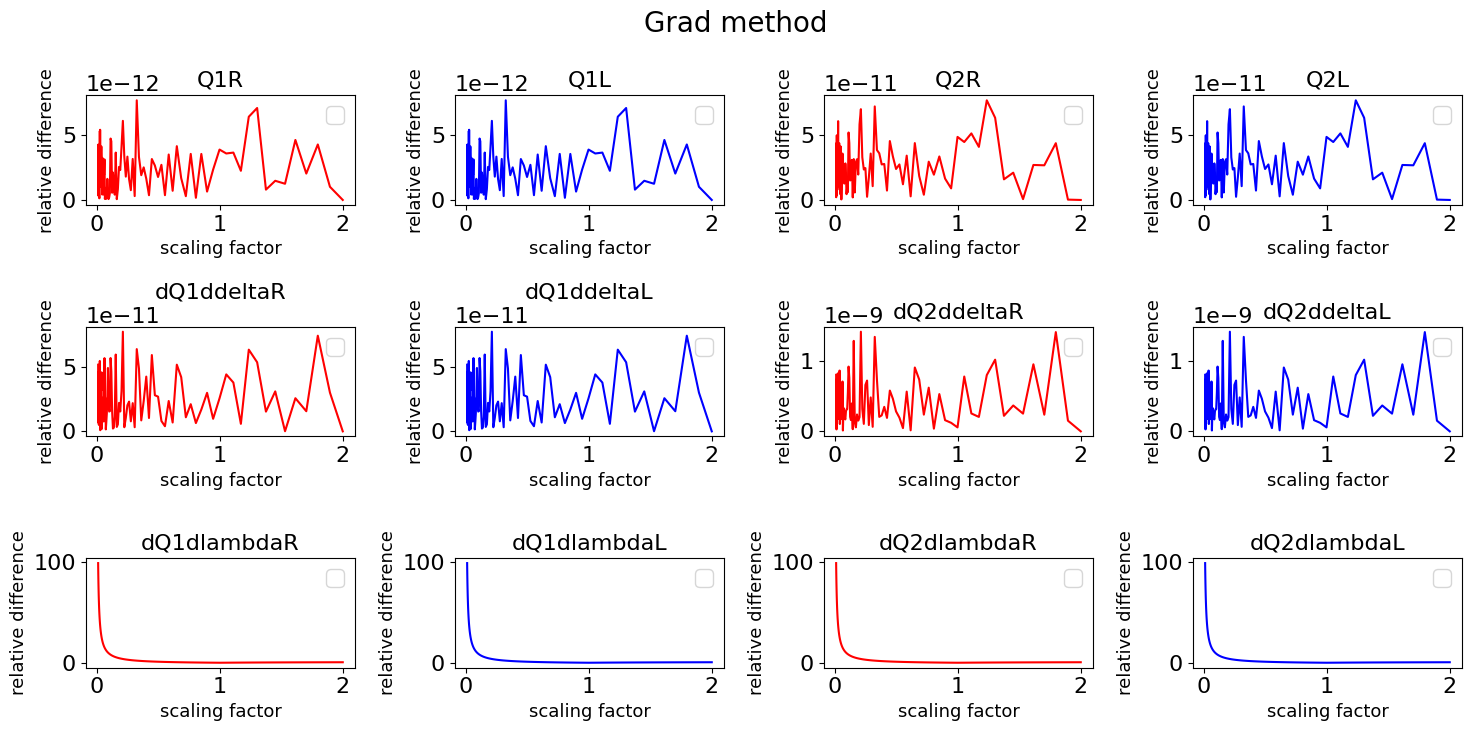

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 4)

axes[0,0].plot(scales, Q1R_g, color='red')
axes[0,0].set_title('Q1R')
axes[0,0].set_xlabel('scaling factor', fontsize = 13)
axes[0,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,0].legend()

axes[0,1].plot(scales, Q1L_g, color='blue')
axes[0,1].set_title('Q1L')
axes[0,1].set_xlabel('scaling factor', fontsize = 13)
axes[0,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,1].legend()

axes[0,2].plot(scales, Q2R_g, color='red')
axes[0,2].set_title('Q2R')
axes[0,2].set_xlabel('scaling factor', fontsize = 13)
axes[0,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,2].legend()

axes[0,3].plot(scales, Q2L_g, color='blue')
axes[0,3].set_title('Q2L')
axes[0,3].set_xlabel('scaling factor', fontsize = 13)
axes[0,3].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,3].legend()

axes[1,0].plot(scales, dQ1ddeltaR_g, color='red')
axes[1,0].set_title('dQ1ddeltaR')
axes[1,0].set_xlabel('scaling factor', fontsize = 13)
axes[1,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,0].legend()

axes[1,1].plot(scales, dQ1ddeltaL_g, color='blue')
axes[1,1].set_title('dQ1ddeltaL')
axes[1,1].set_xlabel('scaling factor', fontsize = 13)
axes[1,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,1].legend()

axes[1,2].plot(scales, dQ2ddeltaR_g, color='red')
axes[1,2].set_title('dQ2ddeltaR')
axes[1,2].set_xlabel('scaling factor', fontsize = 13)
axes[1,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,2].legend()

axes[1,3].plot(scales, dQ2ddeltaL_g, color='blue')
axes[1,3].set_title('dQ2ddeltaL')
axes[1,3].set_xlabel('scaling factor', fontsize = 13)
axes[1,3].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,3].legend()

axes[2,0].plot(scales, dQ1dlambdaR_g, color='red')
axes[2,0].set_title('dQ1dlambdaR')
axes[2,0].set_xlabel('scaling factor', fontsize = 13)
axes[2,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[2,0].legend()

axes[2,1].plot(scales, dQ1dlambdaL_g, color='blue')
axes[2,1].set_title('dQ1dlambdaL')
axes[2,1].set_xlabel('scaling factor', fontsize = 13)
axes[2,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[2,1].legend()

axes[2,2].plot(scales, dQ2dlambdaR_g, color='red')
axes[2,2].set_title('dQ2dlambdaR')
axes[2,2].set_xlabel('scaling factor', fontsize = 13)
axes[2,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[2,2].legend()

axes[2,3].plot(scales, dQ2dlambdaL_g, color='blue')
axes[2,3].set_title('dQ2dlambdaL')
axes[2,3].set_xlabel('scaling factor', fontsize = 13)
axes[2,3].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[2,3].legend()

plt.suptitle('Grad method')

plt.tight_layout()

C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1929640262.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,0].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1929640262.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,1].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1929640262.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1,0].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1929640262.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with

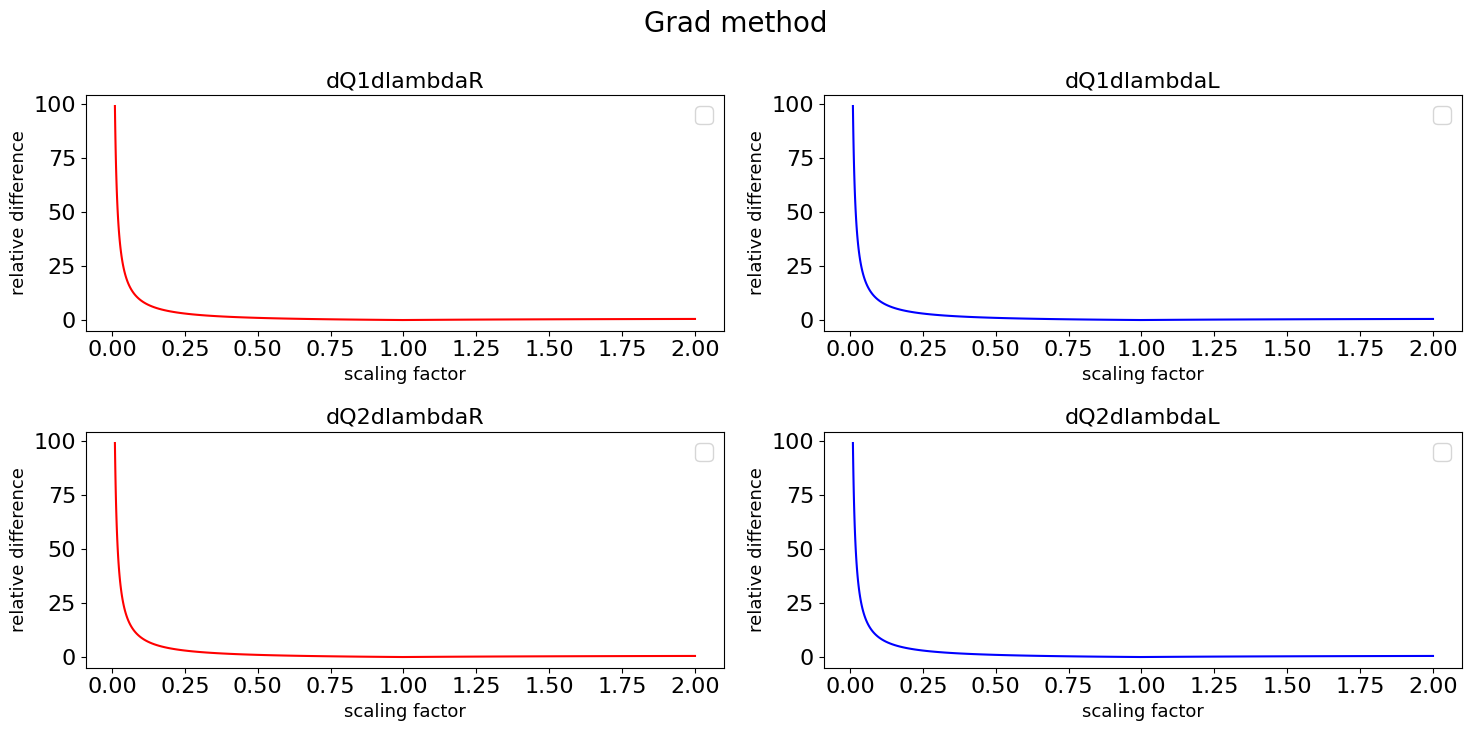

In [38]:
fig, axes = plt.subplots(2, 2)

axes[0,0].plot(scales, dQ1dlambdaR_g, color='red')
axes[0,0].set_title('dQ1dlambdaR')
axes[0,0].set_xlabel('scaling factor', fontsize = 13)
axes[0,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,0].legend()

axes[0,1].plot(scales, dQ1dlambdaL_g, color='blue')
axes[0,1].set_title('dQ1dlambdaL')
axes[0,1].set_xlabel('scaling factor', fontsize = 13)
axes[0,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,1].legend()

axes[1,0].plot(scales, dQ2dlambdaR_g, color='red')
axes[1,0].set_title('dQ2dlambdaR')
axes[1,0].set_xlabel('scaling factor', fontsize = 13)
axes[1,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,0].legend()

axes[1,1].plot(scales, dQ2dlambdaL_g, color='blue')
axes[1,1].set_title('dQ2dlambdaL')
axes[1,1].set_xlabel('scaling factor', fontsize = 13)
axes[1,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,1].legend()

plt.suptitle('Grad method')

plt.tight_layout()

In [39]:
eff1s_g = []
eff2s_g = []
eff3s_g = []
eff4s_g = []
eff5s_g = []
eff6s_g = []

for i in range(0,len(scales)):

    efficiencies = DIFF_EFFICIENCIES_G[i]
    eff1 = DIFF_EFFICIENCIES_G[i][0]
    eff2 = DIFF_EFFICIENCIES_G[i][1]
    eff3 = DIFF_EFFICIENCIES_G[i][2]
    eff4 = DIFF_EFFICIENCIES_G[i][3]
    eff5 = DIFF_EFFICIENCIES_G[i][4]
    eff6 = DIFF_EFFICIENCIES_G[i][5]

    eff1s_g.append(eff1)
    eff2s_g.append(eff2)
    eff3s_g.append(eff3)
    eff4s_g.append(eff4)
    eff5s_g.append(eff5)
    eff6s_g.append(eff6)


C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\2660238504.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,0].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\2660238504.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,1].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\2660238504.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,2].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\2660238504.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with

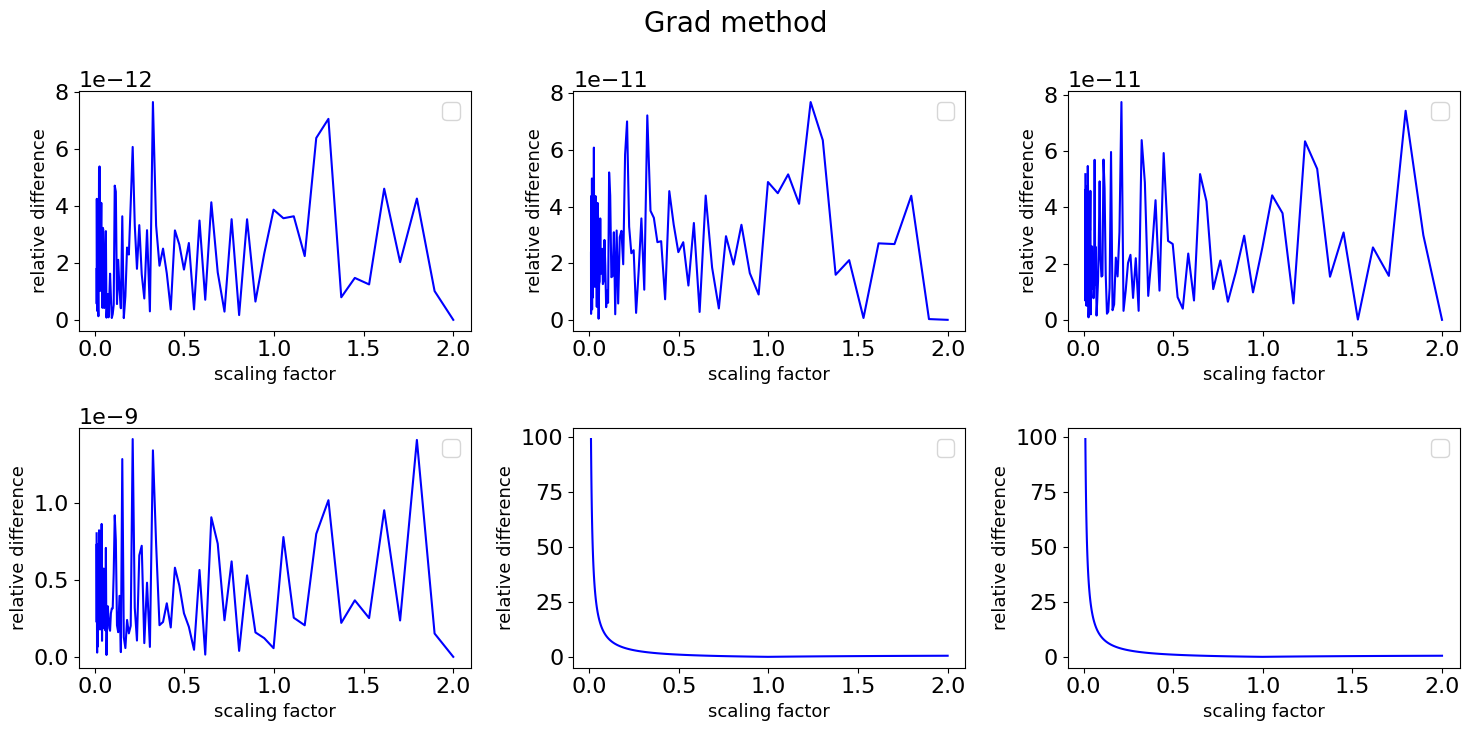

In [40]:
fig, axes = plt.subplots(2, 3)

axes[0,0].plot(scales, eff1s_g, color='blue')
axes[0,0].set_title('')
axes[0,0].set_xlabel('scaling factor', fontsize = 13)
axes[0,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,0].legend()

axes[0,1].plot(scales, eff2s_g, color='blue')
axes[0,1].set_title('')
axes[0,1].set_xlabel('scaling factor', fontsize = 13)
axes[0,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,1].legend()

axes[0,2].plot(scales, eff3s_g, color='blue')
axes[0,2].set_title('')
axes[0,2].set_xlabel('scaling factor', fontsize = 13)
axes[0,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,2].legend()

axes[1,0].plot(scales, eff4s_g, color='blue')
axes[1,0].set_title('')
axes[1,0].set_xlabel('scaling factor', fontsize = 13)
axes[1,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,0].legend()

axes[1,1].plot(scales, eff5s_g, color='blue')
axes[1,1].set_title('')
axes[1,1].set_xlabel('scaling factor', fontsize = 13)
axes[1,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,1].legend()

axes[1,2].plot(scales, eff6s_g, color='blue')
axes[1,2].set_title('')
axes[1,2].set_xlabel('scaling factor', fontsize = 13)
axes[1,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,2].legend()

plt.suptitle('Grad method')

plt.tight_layout()

C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\2881597777.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,0].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\2881597777.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,1].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\2881597777.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,2].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\2881597777.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called wit

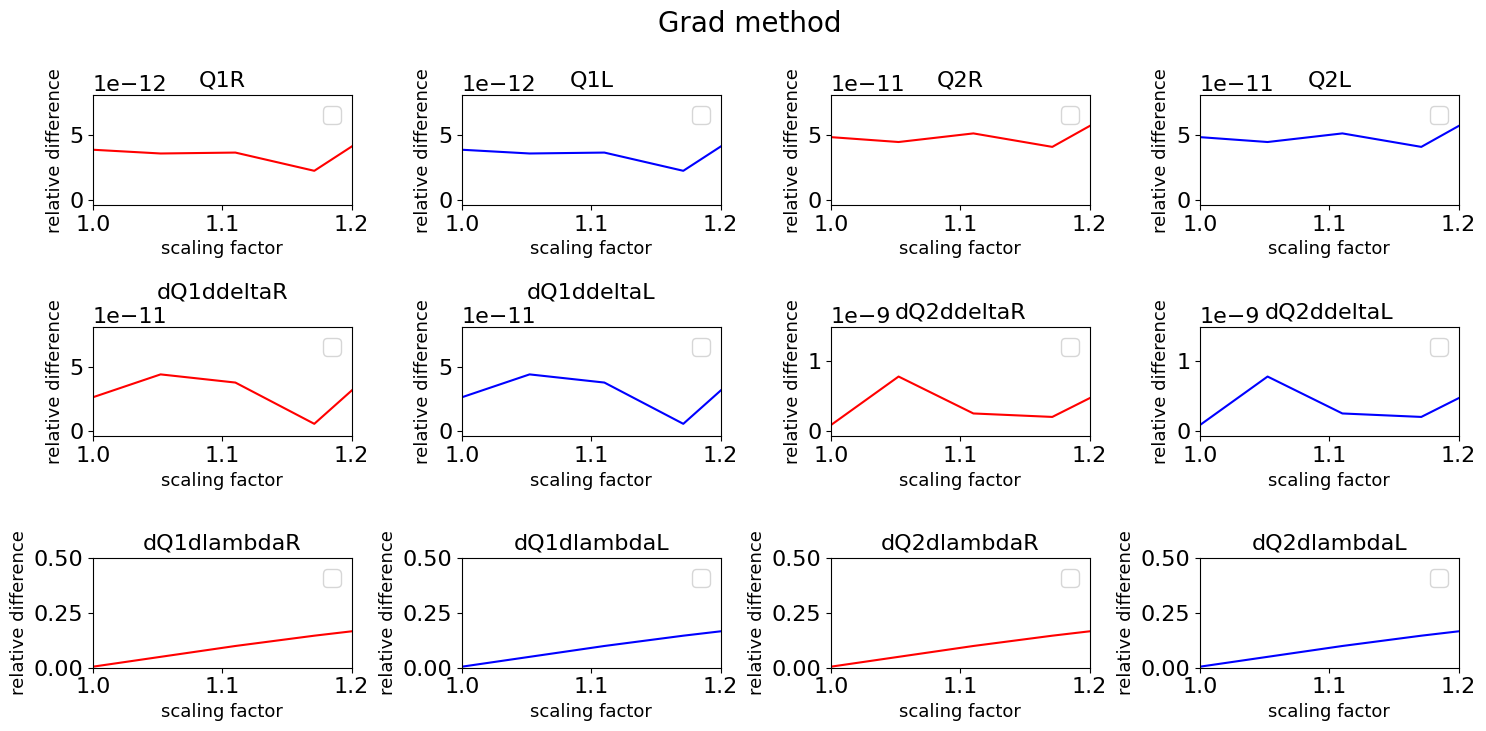

In [41]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 4)

axes[0,0].plot(scales, Q1R_g, color='red')
axes[0,0].set_title('Q1R')
axes[0,0].set_xlabel('scaling factor', fontsize = 13)
axes[0,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,0].set_xlim(1,1.2)
axes[0,0].legend()

axes[0,1].plot(scales, Q1L_g, color='blue')
axes[0,1].set_title('Q1L')
axes[0,1].set_xlabel('scaling factor', fontsize = 13)
axes[0,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,1].set_xlim(1,1.2)
axes[0,1].legend()

axes[0,2].plot(scales, Q2R_g, color='red')
axes[0,2].set_title('Q2R')
axes[0,2].set_xlabel('scaling factor', fontsize = 13)
axes[0,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,2].set_xlim(1,1.2)
axes[0,2].legend()

axes[0,3].plot(scales, Q2L_g, color='blue')
axes[0,3].set_title('Q2L')
axes[0,3].set_xlabel('scaling factor', fontsize = 13)
axes[0,3].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,3].set_xlim(1,1.2)
axes[0,3].legend()

axes[1,0].plot(scales, dQ1ddeltaR_g, color='red')
axes[1,0].set_title('dQ1ddeltaR')
axes[1,0].set_xlabel('scaling factor', fontsize = 13)
axes[1,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,0].set_xlim(1,1.2)
axes[1,0].legend()

axes[1,1].plot(scales, dQ1ddeltaL_g, color='blue')
axes[1,1].set_title('dQ1ddeltaL')
axes[1,1].set_xlabel('scaling factor', fontsize = 13)
axes[1,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,1].set_xlim(1,1.2)
axes[1,1].legend()

axes[1,2].plot(scales, dQ2ddeltaR_g, color='red')
axes[1,2].set_title('dQ2ddeltaR')
axes[1,2].set_xlabel('scaling factor', fontsize = 13)
axes[1,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,2].set_xlim(1,1.2)
axes[1,2].legend()

axes[1,3].plot(scales, dQ2ddeltaL_g, color='blue')
axes[1,3].set_title('dQ2ddeltaL')
axes[1,3].set_xlabel('scaling factor', fontsize = 13)
axes[1,3].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,3].set_xlim(1,1.2)
axes[1,3].legend()

axes[2,0].plot(scales, dQ1dlambdaR_g, color='red')
axes[2,0].set_title('dQ1dlambdaR')
axes[2,0].set_xlabel('scaling factor', fontsize = 13)
axes[2,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[2,0].set_xlim(1,1.2)
axes[2,0].set_ylim(0,0.5)
axes[2,0].legend()

axes[2,1].plot(scales, dQ1dlambdaL_g, color='blue')
axes[2,1].set_title('dQ1dlambdaL')
axes[2,1].set_xlabel('scaling factor', fontsize = 13)
axes[2,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[2,1].set_xlim(1,1.2)
axes[2,1].set_ylim(0,0.5)
axes[2,1].legend()

axes[2,2].plot(scales, dQ2dlambdaR_g, color='red')
axes[2,2].set_title('dQ2dlambdaR')
axes[2,2].set_xlabel('scaling factor', fontsize = 13)
axes[2,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[2,2].set_xlim(1,1.2)
axes[2,2].set_ylim(0,0.5)
axes[2,2].legend()

axes[2,3].plot(scales, dQ2dlambdaL_g, color='blue')
axes[2,3].set_title('dQ2dlambdaL')
axes[2,3].set_xlabel('scaling factor', fontsize = 13)
axes[2,3].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[2,3].set_xlim(1,1.2)
axes[2,3].set_ylim(0,0.5)
axes[2,3].legend()

plt.suptitle('Grad method')

plt.tight_layout()

C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\4270323807.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,0].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\4270323807.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,1].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\4270323807.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1,0].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\4270323807.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with

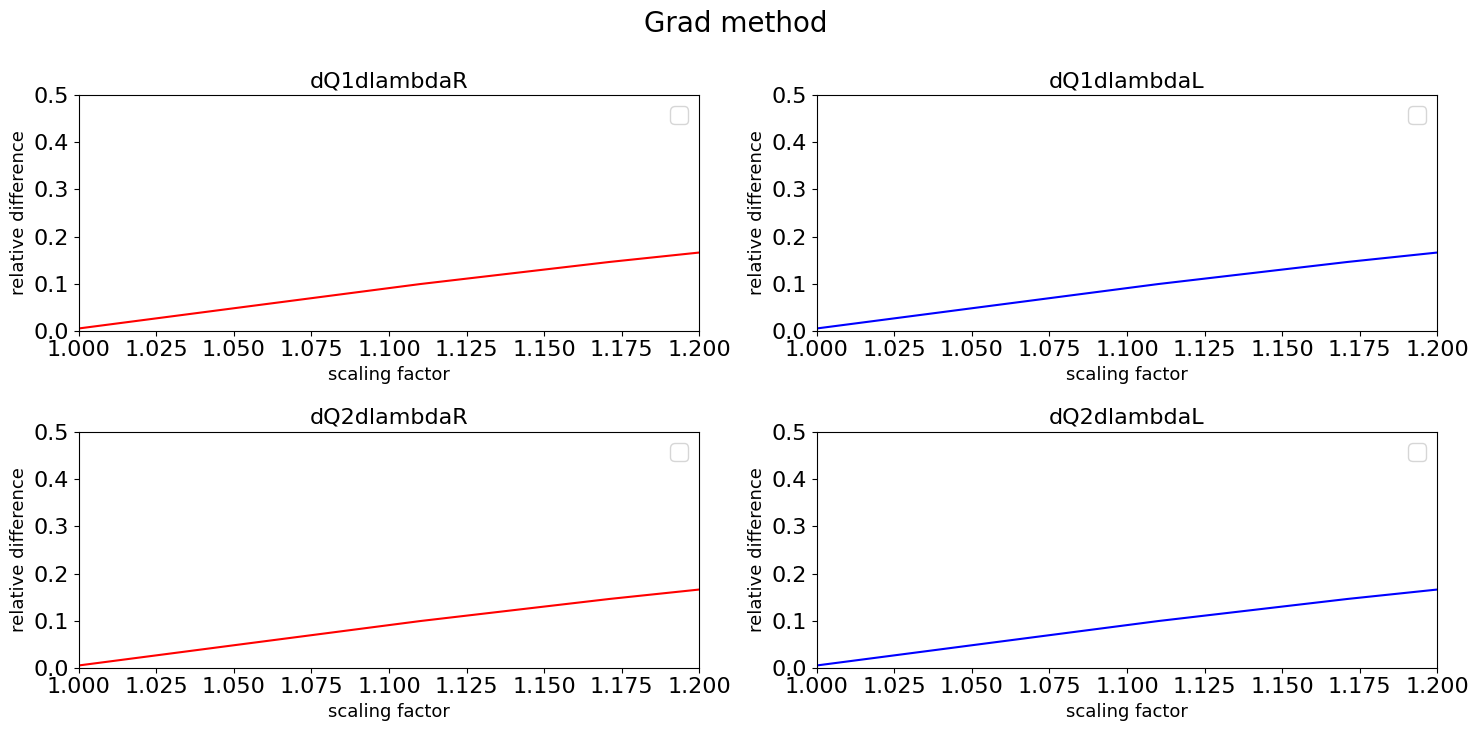

In [42]:
fig, axes = plt.subplots(2, 2)

axes[0,0].plot(scales, dQ1dlambdaR_g, color='red')
axes[0,0].set_title('dQ1dlambdaR')
axes[0,0].set_xlabel('scaling factor', fontsize = 13)
axes[0,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,0].set_xlim(1,1.2)
axes[0,0].set_ylim(0,0.5)
axes[0,0].legend()

axes[0,1].plot(scales, dQ1dlambdaL_g, color='blue')
axes[0,1].set_title('dQ1dlambdaL')
axes[0,1].set_xlabel('scaling factor', fontsize = 13)
axes[0,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,1].set_xlim(1,1.2)
axes[0,1].set_ylim(0,0.5)
axes[0,1].legend()

axes[1,0].plot(scales, dQ2dlambdaR_g, color='red')
axes[1,0].set_title('dQ2dlambdaR')
axes[1,0].set_xlabel('scaling factor', fontsize = 13)
axes[1,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,0].set_xlim(1,1.2)
axes[1,0].set_ylim(0,0.5)
axes[1,0].legend()

axes[1,1].plot(scales, dQ2dlambdaL_g, color='blue')
axes[1,1].set_title('dQ2dlambdaL')
axes[1,1].set_xlabel('scaling factor', fontsize = 13)
axes[1,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,1].set_xlim(1,1.2)
axes[1,1].set_ylim(0,0.5)
axes[1,1].legend()

plt.suptitle('Grad method')

plt.tight_layout()

C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\3898369726.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,0].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\3898369726.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,1].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\3898369726.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,2].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\3898369726.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with

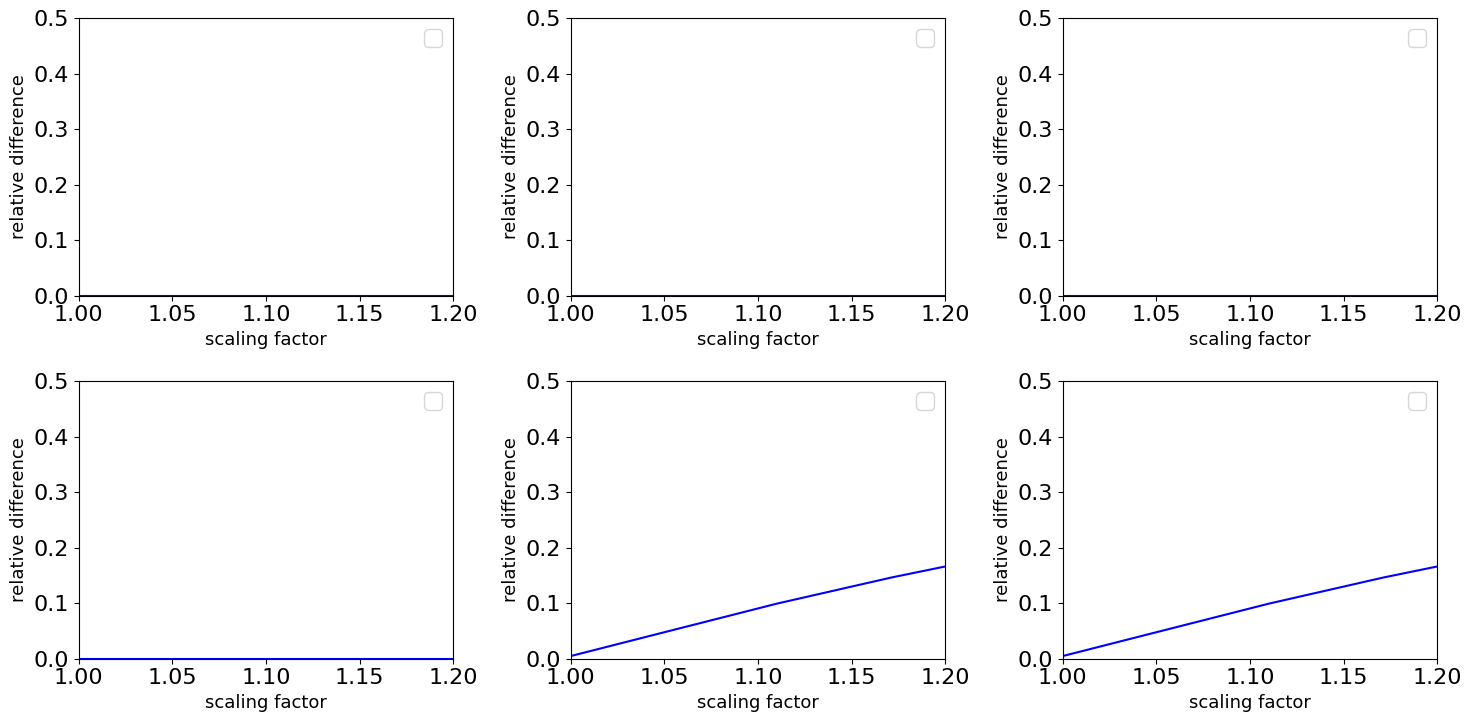

In [43]:
fig, axes = plt.subplots(2, 3)

axes[0,0].plot(scales, eff1s_g, color='blue')
axes[0,0].set_title('')
axes[0,0].set_xlabel('scaling factor', fontsize = 13)
axes[0,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,0].set_xlim(1,1.2)
axes[0,0].set_ylim(0,0.5)
axes[0,0].legend()

axes[0,1].plot(scales, eff2s_g, color='blue')
axes[0,1].set_title('')
axes[0,1].set_xlabel('scaling factor', fontsize = 13)
axes[0,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,1].set_xlim(1,1.2)
axes[0,1].set_ylim(0,0.5)
axes[0,1].legend()

axes[0,2].plot(scales, eff3s_g, color='blue')
axes[0,2].set_title('')
axes[0,2].set_xlabel('scaling factor', fontsize = 13)
axes[0,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,2].set_xlim(1,1.2)
axes[0,2].set_ylim(0,0.5)
axes[0,2].legend()

axes[1,0].plot(scales, eff4s_g, color='blue')
axes[1,0].set_title('')
axes[1,0].set_xlabel('scaling factor', fontsize = 13)
axes[1,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,0].set_xlim(1,1.2)
axes[1,0].set_ylim(0,0.5)
axes[1,0].legend()

axes[1,1].plot(scales, eff5s_g, color='blue')
axes[1,1].set_title('')
axes[1,1].set_xlabel('scaling factor', fontsize = 13)
axes[1,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,1].set_xlim(1,1.2)
axes[1,1].set_ylim(0,0.5)
axes[1,1].legend()

axes[1,2].plot(scales, eff6s_g, color='blue')
axes[1,2].set_title('')
axes[1,2].set_xlabel('scaling factor', fontsize = 13)
axes[1,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,2].set_xlim(1,1.2)
axes[1,2].set_ylim(0,0.5)
axes[1,2].legend()

plt.tight_layout()

In [44]:
####################### USE THIS ONE ########################################################
#THIS TIME WITH FINITE METHOD (NOT GRAD)

calc_foms = []
scales = np.logspace(np.log10(0.01), np.log10(2), 100)

#original Qprs (unscaled)

h_angle = 10**(-6.5)
h_wavelength = 10**(-6.5)

Q1R, Q2R, dQ1ddeltaR, dQ2ddeltaR, dQ1dlambdaR, dQ2dlambdaR = grating.return_Qs(h_angle, h_wavelength)
Q1L = Q1R                ; Q2L = -Q2R;   
dQ1ddeltaL  = -dQ1ddeltaR; dQ2ddeltaL  = dQ2ddeltaR
dQ1dlambdaL = dQ1dlambdaR; dQ2dlambdaL = -dQ2dlambdaR        
Qprs = [Q1R, Q1L, Q2R, Q2L, 
        dQ1ddeltaR, dQ1ddeltaL, dQ2ddeltaR, dQ2ddeltaL, 
        dQ1dlambdaR, dQ1dlambdaL, dQ2dlambdaR, dQ2dlambdaL]

Qprs = np.array([x.item() for x in Qprs])
efficiencies_t = tuple(grating.return_Qs(h_angle, h_wavelength))
efficiencies = np.array([x.detach().cpu().numpy() for x in efficiencies_t])

DIFF_ARRAY_F = []
DIFF_EFFICIENCIES_F = []

for scaled in scales:
    scaled_opt_params = opt_params.copy()

    param_ls = [0, 1, 2, 3, 4, 7, 8]
    for p in param_ls:
        scaled_opt_params[p] = scaled * scaled_opt_params[p]
        
    scaled_grating = TwoBox(*scaled_opt_params, wavelength=scaled, angle=0., 
                            Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                            RCWA_engine=opt_grating.RCWA_engine, 
                            torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

    recorded_fom = fom.multifom(scaled_grating, monofom=fom.monofom_asymp,
                                final_speed=final_speed, goal=0.1, return_grad=False)
    

    h_angle = 10**(-6.5)
    h_wavelength = 10**(-6.5)
    Q1R_s, Q2R_s, dQ1ddeltaR_s, dQ2ddeltaR_s, dQ1dlambdaR_s, dQ2dlambdaR_s = scaled_grating.return_Qs(h_angle, h_wavelength)
    Q1L_s = Q1R_s                ; Q2L_s = -Q2R_s;   
    dQ1ddeltaL_s  = -dQ1ddeltaR_s; dQ2ddeltaL_s  = dQ2ddeltaR_s
    dQ1dlambdaL_s = dQ1dlambdaR_s; dQ2dlambdaL_s = -dQ2dlambdaR_s    
    Qprs_scaled = [Q1R_s, Q1L_s, Q2R_s, Q2L_s, 
            dQ1ddeltaR_s, dQ1ddeltaL_s, dQ2ddeltaR_s, dQ2ddeltaL_s, 
            dQ1dlambdaR_s, dQ1dlambdaL_s, dQ2dlambdaR_s, dQ2dlambdaL_s]
    
    Qprs_scaled = np.array([x.item() for x in Qprs_scaled])
    efficiencies_s = tuple(scaled_grating.return_Qs(h_angle, h_wavelength))
    efficiencies_scaled = np.array([x.detach().cpu().numpy() for x in efficiencies_s])

    #print_grating_params(scaled_grating)
    print(f"FoM at scaled wavelength {scaled}: {recorded_fom}")
    calc_foms.append(recorded_fom)

    Qprs_mag_diff = np.abs((Qprs - Qprs_scaled) / Qprs)
    efficiences_mag_diff = np.abs((efficiencies - efficiencies_scaled) / efficiencies)
    DIFF_ARRAY_F.append(Qprs_mag_diff)
    DIFF_EFFICIENCIES_F.append(efficiences_mag_diff)

    #print(Qprs_mag_diff)
    #print(Qprs_scaled)
    #print(Qprs)




FoM at scaled wavelength 0.01: -305.888768005491
FoM at scaled wavelength 0.01054976358041775: -303.5826596177366
FoM at scaled wavelength 0.011129751160270877: -301.0428749434817
FoM at scaled wavelength 0.011741624344973797: -298.24954450714176
FoM at scaled wavelength 0.012387136088955098: -295.18199769046
FoM at scaled wavelength 0.013068135717693687: -291.8189612852468
FoM at scaled wavelength 0.013786574225848126: -288.1388259688763
FoM at scaled wavelength 0.01454450986665786: -284.1199895766255
FoM at scaled wavelength 0.015344114048629382: -279.7412859230197
FoM at scaled wavelength 0.016187677556400663: -274.98250434121843
FoM at scaled wavelength 0.017077617113606152: -269.8250032740369
FoM at scaled wavelength 0.01801648230654411: -264.25241324641877
FoM at scaled wavelength 0.019006962888481985: -258.2514215973263
FoM at scaled wavelength 0.020051896485525914: -251.81261605429725
FoM at scaled wavelength 0.021154276726130787: -244.93136183039687
FoM at scaled wavelength 0.

In [45]:
Q1R_f = []
Q1L_f = []
Q2R_f = []
Q2L_f = []
dQ1ddeltaR_f = [] 
dQ1ddeltaL_f = []
dQ2ddeltaR_f = []
dQ2ddeltaL_f = [] 
dQ1dlambdaR_f = [] 
dQ1dlambdaL_f = []
dQ2dlambdaR_f = []
dQ2dlambdaL_f = []

for i in range(0,len(scales)):

    Qprs = DIFF_ARRAY_F[i]
    Q1R_s = DIFF_ARRAY_F[i][0]
    Q1L_s = DIFF_ARRAY_F[i][1]
    Q2R_s = DIFF_ARRAY_F[i][2]
    Q2L_s = DIFF_ARRAY_F[i][3]
    dQ1ddeltaR_s = DIFF_ARRAY_F[i][4]
    dQ1ddeltaL_s = DIFF_ARRAY_F[i][5]
    dQ2ddeltaR_s = DIFF_ARRAY_F[i][6]
    dQ2ddeltaL_s = DIFF_ARRAY_F[i][7]
    dQ1dlambdaR_s = DIFF_ARRAY_F[i][8]
    dQ1dlambdaL_s = DIFF_ARRAY_F[i][9]
    dQ2dlambdaR_s = DIFF_ARRAY_F[i][10]
    dQ2dlambdaL_s = DIFF_ARRAY_F[i][11]

    Q1R_f.append(Q1R_s)
    Q1L_f.append(Q1L_s)
    Q2R_f.append(Q2R_s)
    Q2L_f.append(Q2L_s)
    dQ1ddeltaR_f.append(dQ1ddeltaR_s)
    dQ1ddeltaL_f.append(dQ1ddeltaL_s)
    dQ2ddeltaR_f.append(dQ2ddeltaR_s)
    dQ2ddeltaL_f.append(dQ2ddeltaL_s)
    dQ1dlambdaR_f.append(dQ1dlambdaR_s)
    dQ1dlambdaL_f.append(dQ1dlambdaL_s)
    dQ2dlambdaR_f.append(dQ2dlambdaR_s)
    dQ2dlambdaL_f.append(dQ2dlambdaL_s)


C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1209673638.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,0].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1209673638.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,1].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1209673638.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,2].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1209673638.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with

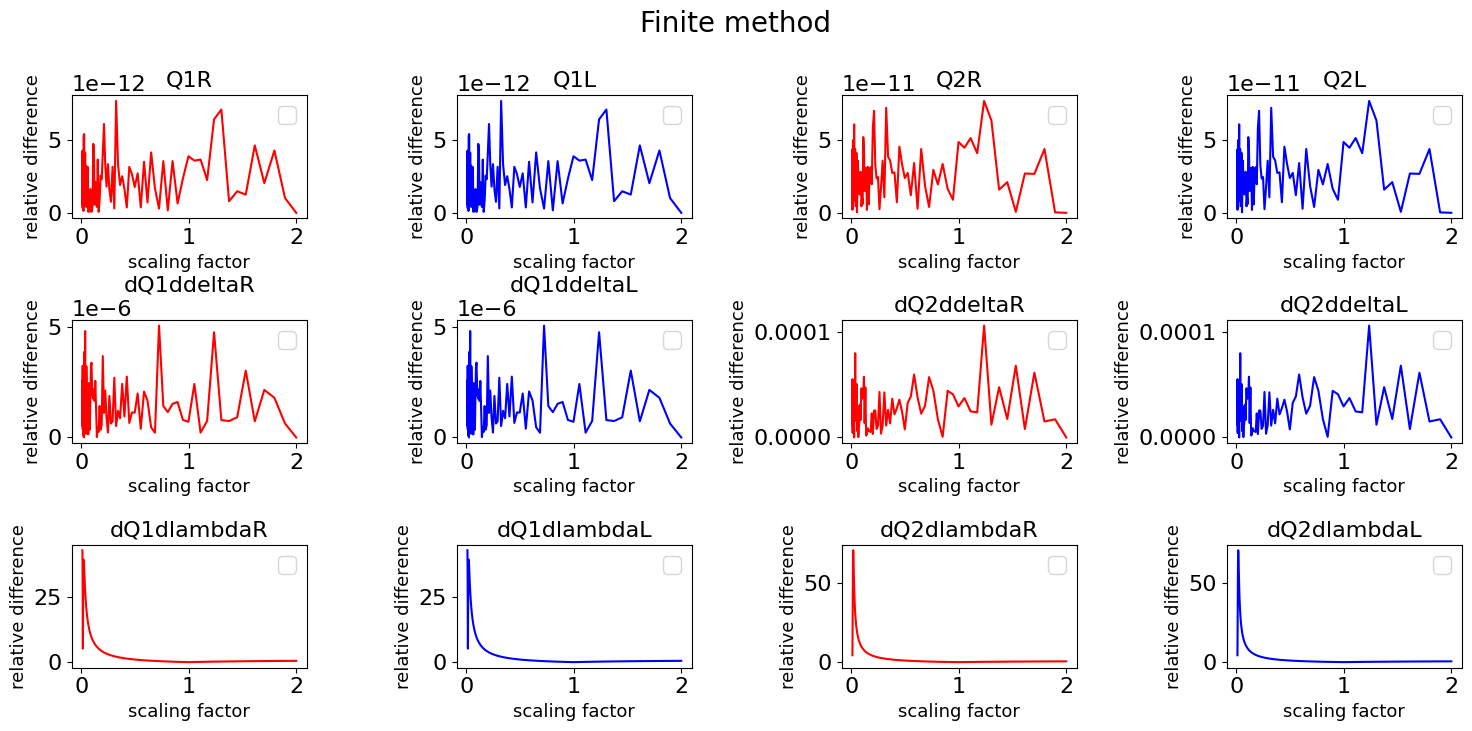

In [46]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 4)

axes[0,0].plot(scales, Q1R_f, color='red')
axes[0,0].set_title('Q1R')
axes[0,0].set_xlabel('scaling factor', fontsize = 13)
axes[0,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,0].legend()

axes[0,1].plot(scales, Q1L_f, color='blue')
axes[0,1].set_title('Q1L')
axes[0,1].set_xlabel('scaling factor', fontsize = 13)
axes[0,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,1].legend()

axes[0,2].plot(scales, Q2R_f, color='red')
axes[0,2].set_title('Q2R')
axes[0,2].set_xlabel('scaling factor', fontsize = 13)
axes[0,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,2].legend()

axes[0,3].plot(scales, Q2L_f, color='blue')
axes[0,3].set_title('Q2L')
axes[0,3].set_xlabel('scaling factor', fontsize = 13)
axes[0,3].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,3].legend()

axes[1,0].plot(scales, dQ1ddeltaR_f, color='red')
axes[1,0].set_title('dQ1ddeltaR')
axes[1,0].set_xlabel('scaling factor', fontsize = 13)
axes[1,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,0].legend()

axes[1,1].plot(scales, dQ1ddeltaL_f, color='blue')
axes[1,1].set_title('dQ1ddeltaL')
axes[1,1].set_xlabel('scaling factor', fontsize = 13)
axes[1,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,1].legend()

axes[1,2].plot(scales, dQ2ddeltaR_f, color='red')
axes[1,2].set_title('dQ2ddeltaR')
axes[1,2].set_xlabel('scaling factor', fontsize = 13)
axes[1,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,2].legend()

axes[1,3].plot(scales, dQ2ddeltaL_f, color='blue')
axes[1,3].set_title('dQ2ddeltaL')
axes[1,3].set_xlabel('scaling factor', fontsize = 13)
axes[1,3].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,3].legend()

axes[2,0].plot(scales, dQ1dlambdaR_f, color='red')
axes[2,0].set_title('dQ1dlambdaR')
axes[2,0].set_xlabel('scaling factor', fontsize = 13)
axes[2,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[2,0].legend()

axes[2,1].plot(scales, dQ1dlambdaL_f, color='blue')
axes[2,1].set_title('dQ1dlambdaL')
axes[2,1].set_xlabel('scaling factor', fontsize = 13)
axes[2,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[2,1].legend()

axes[2,2].plot(scales, dQ2dlambdaR_f, color='red')
axes[2,2].set_title('dQ2dlambdaR')
axes[2,2].set_xlabel('scaling factor', fontsize = 13)
axes[2,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[2,2].legend()

axes[2,3].plot(scales, dQ2dlambdaL_f, color='blue')
axes[2,3].set_title('dQ2dlambdaL')
axes[2,3].set_xlabel('scaling factor', fontsize = 13)
axes[2,3].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[2,3].legend()

plt.suptitle('Finite method')

plt.tight_layout()

C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\579026386.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,0].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\579026386.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,1].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\579026386.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1,0].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\579026386.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no 

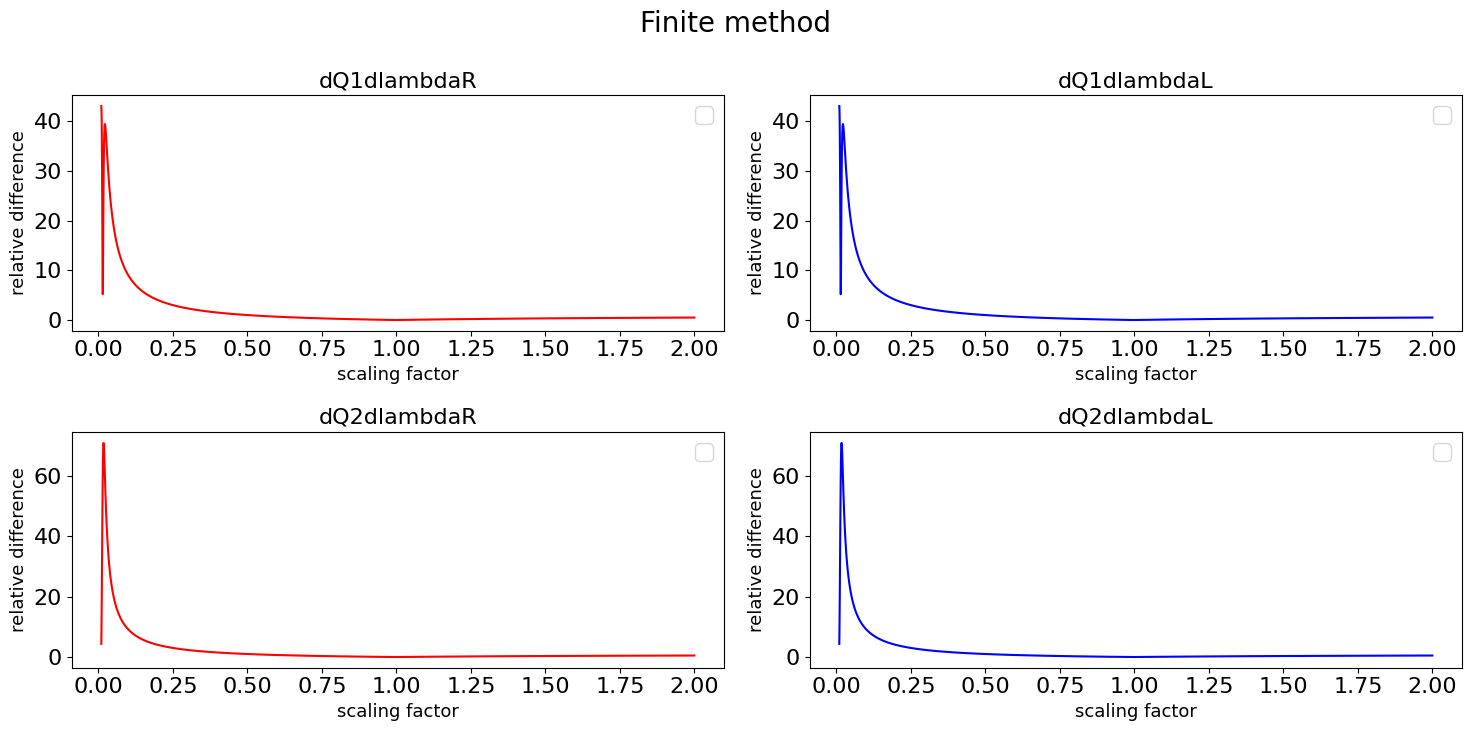

In [47]:
fig, axes = plt.subplots(2, 2)

axes[0,0].plot(scales, dQ1dlambdaR_f, color='red')
axes[0,0].set_title('dQ1dlambdaR')
axes[0,0].set_xlabel('scaling factor', fontsize = 13)
axes[0,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,0].legend()

axes[0,1].plot(scales, dQ1dlambdaL_f, color='blue')
axes[0,1].set_title('dQ1dlambdaL')
axes[0,1].set_xlabel('scaling factor', fontsize = 13)
axes[0,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,1].legend()

axes[1,0].plot(scales, dQ2dlambdaR_f, color='red')
axes[1,0].set_title('dQ2dlambdaR')
axes[1,0].set_xlabel('scaling factor', fontsize = 13)
axes[1,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,0].legend()

axes[1,1].plot(scales, dQ2dlambdaL_f, color='blue')
axes[1,1].set_title('dQ2dlambdaL')
axes[1,1].set_xlabel('scaling factor', fontsize = 13)
axes[1,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,1].legend()

plt.suptitle('Finite method')

plt.tight_layout()

In [49]:
eff1s_f = []
eff2s_f = []
eff3s_f = []
eff4s_f = []
eff5s_f = []
eff6s_f = []

for i in range(0,len(scales)):

    efficiencies = DIFF_EFFICIENCIES_F[i]
    eff1 = DIFF_EFFICIENCIES_F[i][0]
    eff2 = DIFF_EFFICIENCIES_F[i][1]
    eff3 = DIFF_EFFICIENCIES_F[i][2]
    eff4 = DIFF_EFFICIENCIES_F[i][3]
    eff5 = DIFF_EFFICIENCIES_F[i][4]
    eff6 = DIFF_EFFICIENCIES_F[i][5]

    eff1s_f.append(eff1)
    eff2s_f.append(eff2)
    eff3s_f.append(eff3)
    eff4s_f.append(eff4)
    eff5s_f.append(eff5)
    eff6s_f.append(eff6)


C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\734839418.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,0].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\734839418.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,1].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\734839418.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,2].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\734839418.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no 

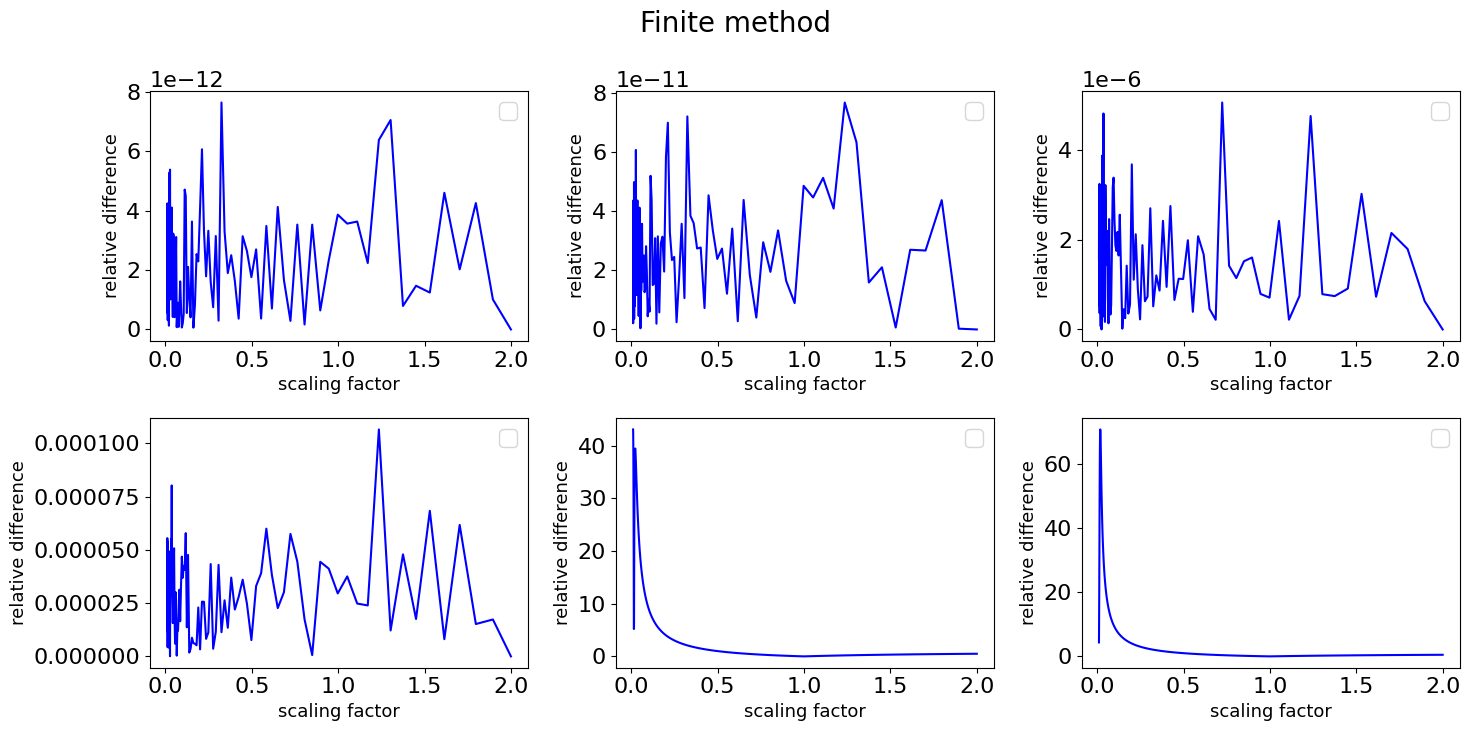

In [50]:
fig, axes = plt.subplots(2, 3)

axes[0,0].plot(scales, eff1s_f, color='blue')
axes[0,0].set_title('')
axes[0,0].set_xlabel('scaling factor', fontsize = 13)
axes[0,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,0].legend()

axes[0,1].plot(scales, eff2s_f, color='blue')
axes[0,1].set_title('')
axes[0,1].set_xlabel('scaling factor', fontsize = 13)
axes[0,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,1].legend()

axes[0,2].plot(scales, eff3s_f, color='blue')
axes[0,2].set_title('')
axes[0,2].set_xlabel('scaling factor', fontsize = 13)
axes[0,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,2].legend()

axes[1,0].plot(scales, eff4s_f, color='blue')
axes[1,0].set_title('')
axes[1,0].set_xlabel('scaling factor', fontsize = 13)
axes[1,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,0].legend()

axes[1,1].plot(scales, eff5s_f, color='blue')
axes[1,1].set_title('')
axes[1,1].set_xlabel('scaling factor', fontsize = 13)
axes[1,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,1].legend()

axes[1,2].plot(scales, eff6s_f, color='blue')
axes[1,2].set_title('')
axes[1,2].set_xlabel('scaling factor', fontsize = 13)
axes[1,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,2].legend()

plt.suptitle('Finite method')

plt.tight_layout()

C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\3578223676.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,0].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\3578223676.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,1].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\3578223676.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,2].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\3578223676.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called wit

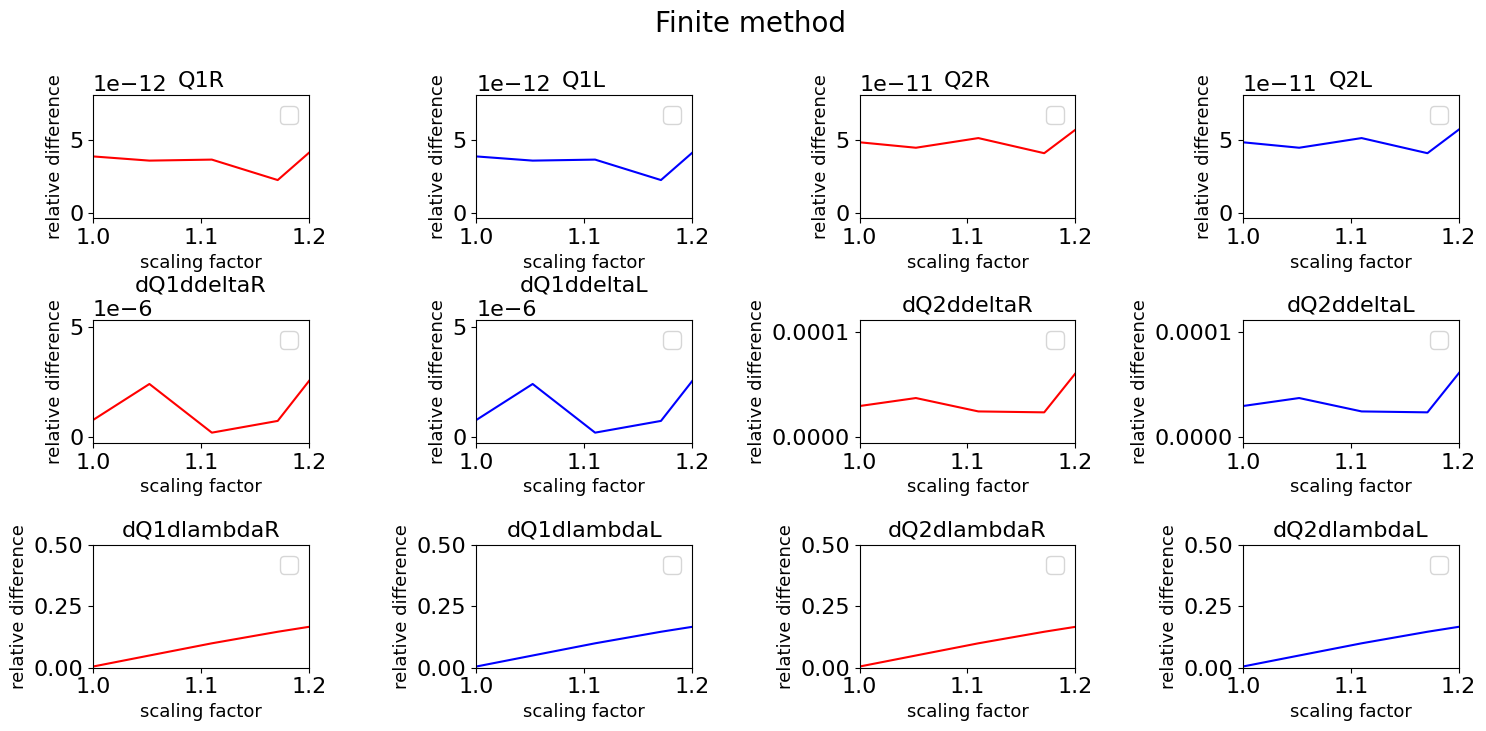

In [51]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 4)

axes[0,0].plot(scales, Q1R_f, color='red')
axes[0,0].set_title('Q1R')
axes[0,0].set_xlabel('scaling factor', fontsize = 13)
axes[0,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,0].set_xlim(1,1.2)
axes[0,0].legend()

axes[0,1].plot(scales, Q1L_f, color='blue')
axes[0,1].set_title('Q1L')
axes[0,1].set_xlabel('scaling factor', fontsize = 13)
axes[0,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,1].set_xlim(1,1.2)
axes[0,1].legend()

axes[0,2].plot(scales, Q2R_f, color='red')
axes[0,2].set_title('Q2R')
axes[0,2].set_xlabel('scaling factor', fontsize = 13)
axes[0,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,2].set_xlim(1,1.2)
axes[0,2].legend()

axes[0,3].plot(scales, Q2L_f, color='blue')
axes[0,3].set_title('Q2L')
axes[0,3].set_xlabel('scaling factor', fontsize = 13)
axes[0,3].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,3].set_xlim(1,1.2)
axes[0,3].legend()

axes[1,0].plot(scales, dQ1ddeltaR_f, color='red')
axes[1,0].set_title('dQ1ddeltaR')
axes[1,0].set_xlabel('scaling factor', fontsize = 13)
axes[1,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,0].set_xlim(1,1.2)
axes[1,0].legend()

axes[1,1].plot(scales, dQ1ddeltaL_f, color='blue')
axes[1,1].set_title('dQ1ddeltaL')
axes[1,1].set_xlabel('scaling factor', fontsize = 13)
axes[1,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,1].set_xlim(1,1.2)
axes[1,1].legend()

axes[1,2].plot(scales, dQ2ddeltaR_f, color='red')
axes[1,2].set_title('dQ2ddeltaR')
axes[1,2].set_xlabel('scaling factor', fontsize = 13)
axes[1,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,2].set_xlim(1,1.2)
axes[1,2].legend()

axes[1,3].plot(scales, dQ2ddeltaL_f, color='blue')
axes[1,3].set_title('dQ2ddeltaL')
axes[1,3].set_xlabel('scaling factor', fontsize = 13)
axes[1,3].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,3].set_xlim(1,1.2)
axes[1,3].legend()

axes[2,0].plot(scales, dQ1dlambdaR_f, color='red')
axes[2,0].set_title('dQ1dlambdaR')
axes[2,0].set_xlabel('scaling factor', fontsize = 13)
axes[2,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[2,0].set_xlim(1,1.2)
axes[2,0].set_ylim(0,0.5)
axes[2,0].legend()

axes[2,1].plot(scales, dQ1dlambdaL_f, color='blue')
axes[2,1].set_title('dQ1dlambdaL')
axes[2,1].set_xlabel('scaling factor', fontsize = 13)
axes[2,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[2,1].set_xlim(1,1.2)
axes[2,1].set_ylim(0,0.5)
axes[2,1].legend()

axes[2,2].plot(scales, dQ2dlambdaR_f, color='red')
axes[2,2].set_title('dQ2dlambdaR')
axes[2,2].set_xlabel('scaling factor', fontsize = 13)
axes[2,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[2,2].set_xlim(1,1.2)
axes[2,2].set_ylim(0,0.5)
axes[2,2].legend()

axes[2,3].plot(scales, dQ2dlambdaL_f, color='blue')
axes[2,3].set_title('dQ2dlambdaL')
axes[2,3].set_xlabel('scaling factor', fontsize = 13)
axes[2,3].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[2,3].set_xlim(1,1.2)
axes[2,3].set_ylim(0,0.5)
axes[2,3].legend()

plt.suptitle('Finite method')
plt.tight_layout()

C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1813112029.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,0].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1813112029.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,1].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1813112029.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1,0].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1813112029.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with

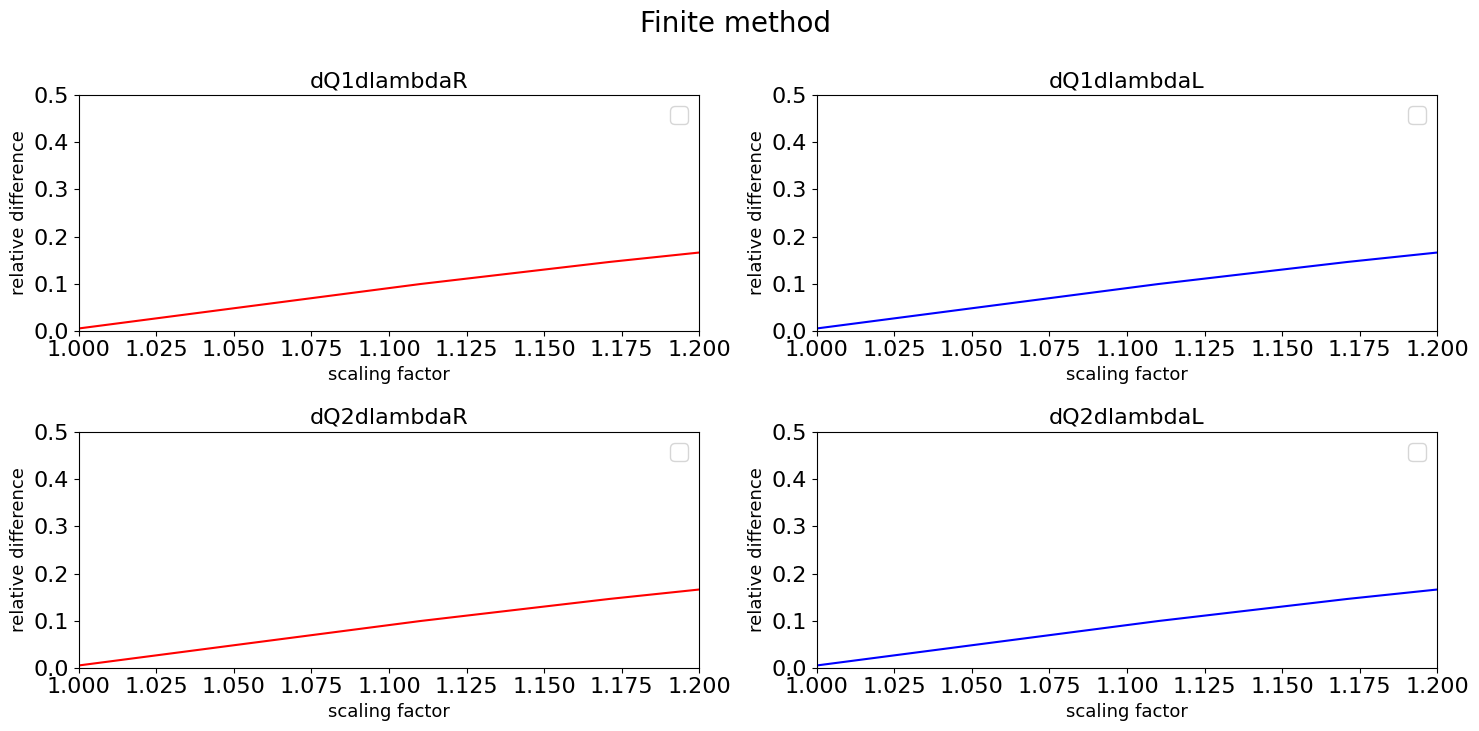

In [52]:
fig, axes = plt.subplots(2, 2)

axes[0,0].plot(scales, dQ1dlambdaR_f, color='red')
axes[0,0].set_title('dQ1dlambdaR')
axes[0,0].set_xlabel('scaling factor', fontsize = 13)
axes[0,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,0].set_xlim(1,1.2)
axes[0,0].set_ylim(0,0.5)
axes[0,0].legend()

axes[0,1].plot(scales, dQ1dlambdaL_f, color='blue')
axes[0,1].set_title('dQ1dlambdaL')
axes[0,1].set_xlabel('scaling factor', fontsize = 13)
axes[0,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,1].set_xlim(1,1.2)
axes[0,1].set_ylim(0,0.5)
axes[0,1].legend()

axes[1,0].plot(scales, dQ2dlambdaR_f, color='red')
axes[1,0].set_title('dQ2dlambdaR')
axes[1,0].set_xlabel('scaling factor', fontsize = 13)
axes[1,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,0].set_xlim(1,1.2)
axes[1,0].set_ylim(0,0.5)
axes[1,0].legend()

axes[1,1].plot(scales, dQ2dlambdaL_f, color='blue')
axes[1,1].set_title('dQ2dlambdaL')
axes[1,1].set_xlabel('scaling factor', fontsize = 13)
axes[1,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,1].set_xlim(1,1.2)
axes[1,1].set_ylim(0,0.5)
axes[1,1].legend()

plt.suptitle('Finite method')

plt.tight_layout()

C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1429386517.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,0].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1429386517.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,1].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1429386517.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,2].legend()
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1429386517.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with

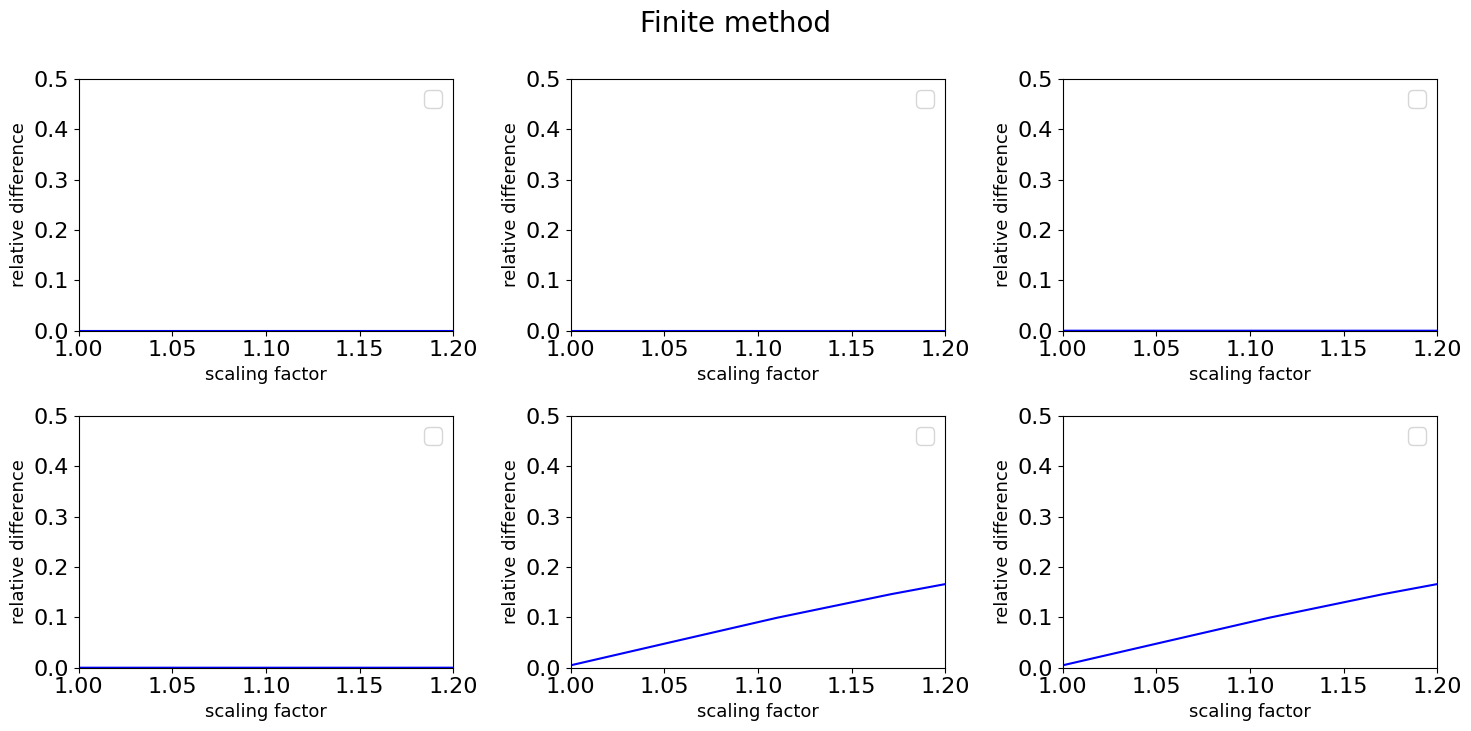

In [53]:
fig, axes = plt.subplots(2, 3)

axes[0,0].plot(scales, eff1s_f, color='blue')
axes[0,0].set_title('')
axes[0,0].set_xlabel('scaling factor', fontsize = 13)
axes[0,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,0].set_xlim(1,1.2)
axes[0,0].set_ylim(0,0.5)
axes[0,0].legend()

axes[0,1].plot(scales, eff2s_f, color='blue')
axes[0,1].set_title('')
axes[0,1].set_xlabel('scaling factor', fontsize = 13)
axes[0,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,1].set_xlim(1,1.2)
axes[0,1].set_ylim(0,0.5)
axes[0,1].legend()

axes[0,2].plot(scales, eff3s_f, color='blue')
axes[0,2].set_title('')
axes[0,2].set_xlabel('scaling factor', fontsize = 13)
axes[0,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[0,2].set_xlim(1,1.2)
axes[0,2].set_ylim(0,0.5)
axes[0,2].legend()

axes[1,0].plot(scales, eff4s_f, color='blue')
axes[1,0].set_title('')
axes[1,0].set_xlabel('scaling factor', fontsize = 13)
axes[1,0].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,0].set_xlim(1,1.2)
axes[1,0].set_ylim(0,0.5)
axes[1,0].legend()

axes[1,1].plot(scales, eff5s_f, color='blue')
axes[1,1].set_title('')
axes[1,1].set_xlabel('scaling factor', fontsize = 13)
axes[1,1].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,1].set_xlim(1,1.2)
axes[1,1].set_ylim(0,0.5)
axes[1,1].legend()

axes[1,2].plot(scales, eff6s_f, color='blue')
axes[1,2].set_title('')
axes[1,2].set_xlabel('scaling factor', fontsize = 13)
axes[1,2].set_ylabel('relative difference', fontsize = 13) #relative to unscaled grating
axes[1,2].set_xlim(1,1.2)
axes[1,2].set_ylim(0,0.5)
axes[1,2].legend()

plt.suptitle('Finite method')

plt.tight_layout()

In [75]:
#######################COMPARISON BETWEEN GRAD AND FINITE###########################################

Q1R_g = np.array([x.item() for x in Q1R_g])
Q1R_f = np.array([x.item() for x in Q1R_f])

Q1L_g = np.array([x.item() for x in Q1L_g])
Q1L_f = np.array([x.item() for x in Q1L_f])

Q2R_g = np.array([x.item() for x in Q2R_g])
Q2R_f = np.array([x.item() for x in Q2R_f])

Q2L_g = np.array([x.item() for x in Q2L_g])
Q2L_f = np.array([x.item() for x in Q2L_f])

dQ1ddeltaR_g = np.array([x.item() for x in dQ1ddeltaR_g])
dQ1ddeltaR_f = np.array([x.item() for x in dQ1ddeltaR_f])

dQ1ddeltaL_g = np.array([x.item() for x in dQ1ddeltaL_g])
dQ1ddeltaL_f = np.array([x.item() for x in dQ1ddeltaL_f])

dQ2ddeltaR_g = np.array([x.item() for x in dQ2ddeltaR_g])
dQ2ddeltaR_f = np.array([x.item() for x in dQ2ddeltaR_f])

dQ2ddeltaL_g = np.array([x.item() for x in dQ2ddeltaL_g])
dQ2ddeltaL_f = np.array([x.item() for x in dQ2ddeltaL_f])

dQ1dlambdaR_g = np.array([x.item() for x in dQ1dlambdaR_g])
dQ1dlambdaR_f = np.array([x.item() for x in dQ1dlambdaR_f])

dQ1dlambdaL_g = np.array([x.item() for x in dQ1dlambdaL_g])
dQ1dlambdaL_f = np.array([x.item() for x in dQ1dlambdaL_f])

dQ2dlambdaR_g = np.array([x.item() for x in dQ2dlambdaR_g])
dQ2dlambdaR_f = np.array([x.item() for x in dQ2dlambdaR_f])

dQ2dlambdaL_g = np.array([x.item() for x in dQ2dlambdaL_g])
dQ2dlambdaL_f = np.array([x.item() for x in dQ2dlambdaL_f])

'''
Q1R_diff = (Q1R_g - Q1R_f) / Q1R_g
Q1L_diff = (Q1L_g - Q1L_f) / Q1L_g
Q2R_diff = (Q2R_g - Q2R_f) / Q2R_g 
Q2L_diff = (Q2L_g - Q2L_f) / Q2L_g
dQ1ddeltaR_diff = (dQ1ddeltaR_g - dQ1ddeltaR_f) / dQ1ddeltaR_g
dQ1ddeltaL_diff = (dQ1ddeltaL_g - dQ1ddeltaL_f) / dQ1ddeltaL_g
dQ2ddeltaR_diff = (dQ2ddeltaR_g - dQ2ddeltaR_f) / dQ2ddeltaR_g
dQ2ddeltaL_diff = (dQ2ddeltaL_g - dQ2ddeltaL_f) / dQ2ddeltaL_g
dQ1dlambdaR_diff = (dQ1dlambdaR_g - dQ1dlambdaR_f) / dQ1dlambdaR_g
dQ1dlambdaL_diff = (dQ1dlambdaL_g - dQ1dlambdaL_f) / dQ1dlambdaL_g
dQ2dlambdaR_diff = (dQ2dlambdaR_g - dQ2dlambdaR_f) / dQ2dlambdaR_g
dQ2dlambdaL_diff = (dQ2dlambdaL_g - dQ2dlambdaL_f) / dQ2dlambdaL_g
'''


Q1R_diff = Q1R_g / Q1R_f
Q1L_diff = Q1L_g / Q1L_f
Q2R_diff = Q2R_g / Q2R_f
Q2L_diff = Q2L_g / Q2L_f
dQ1ddeltaR_diff = dQ1ddeltaR_g / dQ1ddeltaR_f
dQ1ddeltaL_diff = dQ1ddeltaL_g / dQ1ddeltaL_f
dQ2ddeltaR_diff = dQ2ddeltaR_g / dQ2ddeltaR_f
dQ2ddeltaL_diff = dQ2ddeltaL_g / dQ2ddeltaL_f
dQ1dlambdaR_diff = dQ1dlambdaR_g / dQ1dlambdaR_f
dQ1dlambdaL_diff = dQ1dlambdaL_g / dQ1dlambdaL_f
dQ2dlambdaR_diff = dQ2dlambdaR_g / dQ2dlambdaR_f
dQ2dlambdaL_diff = dQ2dlambdaL_g / dQ2dlambdaL_f


print(Q1R_diff)
print(Q1L_diff)
print(Q2R_diff)
print(Q2L_diff)
print(dQ1ddeltaR_diff)
print(dQ1ddeltaL_diff)
print(dQ2ddeltaR_diff)
print(dQ2ddeltaL_diff)
print(dQ1dlambdaR_diff)
print(dQ1dlambdaL_diff)
print(dQ2dlambdaR_diff)
print(dQ2dlambdaL_diff)


[ 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1. nan]
[ 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1. nan]
[ 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.

C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1702185883.py:55: RuntimeWarning: invalid value encountered in divide
  Q1R_diff = Q1R_g / Q1R_f
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1702185883.py:56: RuntimeWarning: invalid value encountered in divide
  Q1L_diff = Q1L_g / Q1L_f
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1702185883.py:57: RuntimeWarning: invalid value encountered in divide
  Q2R_diff = Q2R_g / Q2R_f
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1702185883.py:58: RuntimeWarning: invalid value encountered in divide
  Q2L_diff = Q2L_g / Q2L_f
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1702185883.py:59: RuntimeWarning: invalid value encountered in divide
  dQ1ddeltaR_diff = dQ1ddeltaR_g / dQ1ddeltaR_f
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1702185883.py:60: RuntimeWarning: invalid value encountered in divide
  dQ1ddeltaL_diff = dQ1ddeltaL_g / dQ1ddeltaL_f
C:\Users\rosew\AppData\Local\Temp\ipykernel_21244\1702185883.py:61: RuntimeW

In [63]:
print(Q1R_diff)


[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0. nan]


In [64]:
print(Q1L_diff)


[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0. nan]


In [65]:
print(Q2R_diff)


[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0. nan]


In [66]:
print(Q2L_diff)


[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0. nan]


In [67]:
print(dQ1ddeltaR_diff)



[-3.01356125e+04 -3.79977698e+05 -2.32835991e+04 -8.17654145e+04
 -5.90733096e+04 -3.31835602e+05 -1.24741275e+04 -1.05944993e+05
 -8.38268612e+04 -1.17526622e+05 -3.76665664e+04 -1.51377585e+05
 -1.71411623e+04 -2.13442840e+03 -4.88646301e+04 -2.87967586e+04
 -2.01865527e+04 -1.45449018e+01 -4.39775109e+04 -4.52135263e+05
 -7.34220415e+05 -7.35359132e+04 -5.05389855e+04 -5.78708932e+04
 -1.51072259e+05 -6.34433383e+03 -3.51686068e+05 -2.83084949e+04
 -1.53202916e+04 -1.23230027e+05 -1.73281180e+05 -7.17728351e+04
 -2.36019640e+05 -1.95672468e+05 -1.27542062e+04 -1.10899321e+04
 -9.50593865e+04 -6.01871340e+05 -4.66390618e+04 -3.91798974e+04
 -6.60241013e+04 -6.42825862e+04 -1.57073445e+05 -1.57579547e+05
 -1.18773692e+05 -3.06973667e+04 -4.65205939e+04 -1.03735191e+05
 -1.17308654e+06 -4.55254051e+05 -1.63786294e+03 -7.53661675e+03
 -7.34158761e+04 -2.58867268e+05 -1.60037844e+04 -3.61961509e+04
 -1.17771863e+05 -1.43089998e+04 -6.63231719e+05 -8.56617093e+04
 -1.10737358e+04 -8.12237

In [68]:
print(dQ1ddeltaL_diff)


[-3.01356125e+04 -3.79977698e+05 -2.32835991e+04 -8.17654145e+04
 -5.90733096e+04 -3.31835602e+05 -1.24741275e+04 -1.05944993e+05
 -8.38268612e+04 -1.17526622e+05 -3.76665664e+04 -1.51377585e+05
 -1.71411623e+04 -2.13442840e+03 -4.88646301e+04 -2.87967586e+04
 -2.01865527e+04 -1.45449018e+01 -4.39775109e+04 -4.52135263e+05
 -7.34220415e+05 -7.35359132e+04 -5.05389855e+04 -5.78708932e+04
 -1.51072259e+05 -6.34433383e+03 -3.51686068e+05 -2.83084949e+04
 -1.53202916e+04 -1.23230027e+05 -1.73281180e+05 -7.17728351e+04
 -2.36019640e+05 -1.95672468e+05 -1.27542062e+04 -1.10899321e+04
 -9.50593865e+04 -6.01871340e+05 -4.66390618e+04 -3.91798974e+04
 -6.60241013e+04 -6.42825862e+04 -1.57073445e+05 -1.57579547e+05
 -1.18773692e+05 -3.06973667e+04 -4.65205939e+04 -1.03735191e+05
 -1.17308654e+06 -4.55254051e+05 -1.63786294e+03 -7.53661675e+03
 -7.34158761e+04 -2.58867268e+05 -1.60037844e+04 -3.61961509e+04
 -1.17771863e+05 -1.43089998e+04 -6.63231719e+05 -8.56617093e+04
 -1.10737358e+04 -8.12237

In [69]:
print(dQ2ddeltaR_diff)
print(dQ2ddeltaL_diff)


[-3.01845426e+04 -2.46696199e+05 -3.30529322e+04 -1.28400871e+05
 -8.83049766e+04 -1.29127376e+06 -6.19060913e+04 -3.00434860e+04
 -3.10087660e+05 -6.67920376e+05 -5.30962744e+04 -8.62217404e+04
 -1.48474955e+05 -6.50259954e+03 -3.98985522e+04 -2.56481804e+04
 -5.99281619e+04 -2.38243419e+04 -2.00123513e+02 -2.20963152e+05
 -2.09664313e+05 -4.60754736e+04 -9.15827116e+04 -8.80527812e+04
 -1.31863903e+05 -3.78312643e+04 -2.38523242e+05 -3.29101373e+04
 -1.42030008e+05 -1.19387272e+05 -8.86152045e+04 -9.75099115e+04
 -1.69923179e+04 -1.75298133e+05 -3.73635067e+04 -2.90243553e+04
 -5.06202608e+04 -3.66978145e+04 -7.65492349e+04 -1.67686406e+05
 -9.74906829e+04 -1.15178406e+05 -1.49735804e+05 -1.17247867e+05
 -7.82586470e+04 -4.42156754e+04 -7.65153569e+04 -6.67579398e+04
 -2.98013375e+05 -4.51939484e+03 -1.13624409e+05 -6.82058171e+03
 -4.87909032e+04 -1.04760105e+05 -2.17819072e+04 -1.50905708e+05
 -1.62759712e+04 -1.81855698e+04 -8.05558690e+04 -7.76061646e+04
 -1.70748081e+04 -6.01673

In [70]:
print(dQ1dlambdaR_diff)
print(dQ1dlambdaL_diff)
print(dQ2dlambdaR_diff)
print(dQ2dlambdaL_diff)


[ 5.64994768e-01  5.47631568e-01  5.43338282e-01  5.58596658e-01
  6.00410330e-01  6.74626685e-01  7.83476762e-01  9.23308284e-01
  9.15890518e-01  7.48216458e-01  5.87757760e-01  4.44972868e-01
  3.25210649e-01  2.29319491e-01  1.55242388e-01  9.95826574e-02
  5.86864253e-02  2.92214895e-02  8.40191685e-03 -5.98563838e-03
 -1.56453006e-02 -2.18635655e-02 -2.55996210e-02 -2.75629156e-02
 -2.82753707e-02 -2.81194200e-02 -2.73742973e-02 -2.62430992e-02
 -2.48728286e-02 -2.33691845e-02 -2.18074659e-02 -2.02406092e-02
 -1.87051206e-02 -1.72254598e-02 -1.58172858e-02 -1.44898598e-02
 -1.32478294e-02 -1.20925524e-02 -1.10230772e-02 -1.00368692e-02
 -9.13034762e-03 -8.29927984e-03 -7.53906875e-03 -6.84496226e-03
 -6.21220014e-03 -5.63611918e-03 -5.11222489e-03 -4.63623569e-03
 -4.20411242e-03 -3.81207171e-03 -3.45659200e-03 -3.13441033e-03
 -2.84251651e-03 -2.57814110e-03 -2.33874548e-03 -2.12200652e-03
 -1.92580345e-03 -1.74820210e-03 -1.58744487e-03 -1.44193099e-03
 -1.31020810e-03 -1.19095

In [76]:
##################AGAIN BUT FOR THE REGION OF INTEREST (BETWEEN 1 AND 1.2 ISH)###########################################################

mask = (1 < scales) & (scales < 1.3)

print('Ratio grad_rel_diff / finite_rel_diff, dQ1ddeltaR:', abs(dQ1ddeltaR_diff[mask]))
print('Ratio grad_rel_diff / finite_rel_diff, dQ1ddeltaL:', abs(dQ1ddeltaL_diff[mask]))
print('Ratio grad_rel_diff / finite_rel_diff, dQ2ddeltaR:', abs(dQ2ddeltaR_diff[mask]))
print('Ratio grad_rel_diff / finite_rel_diff, dQ2ddeltaL:', abs(dQ2ddeltaL_diff[mask]))
print('Ratio grad_rel_diff / finite_rel_diff, dQ1dlambdaR:', abs(dQ1dlambdaR_diff[mask]))
print('Ratio grad_rel_diff / finite_rel_diff, dQ1dlambdaL:', abs(dQ1dlambdaL_diff[mask]))
print('Ratio grad_rel_diff / finite_rel_diff, dQ2dlambdaR:', abs(dQ2dlambdaR_diff[mask]))
print('Ratio grad_rel_diff / finite_rel_diff, dQ2dlambdaL:', abs(dQ2dlambdaL_diff[mask]))

Ratio grad_rel_diff / finite_rel_diff, dQ1ddeltaR: [1.83137132e-05 1.74336053e-04 7.81686946e-06 1.33513510e-05]
Ratio grad_rel_diff / finite_rel_diff, dQ1ddeltaL: [1.83137132e-05 1.74336053e-04 7.81686946e-06 1.33513510e-05]
Ratio grad_rel_diff / finite_rel_diff, dQ2ddeltaR: [2.06940026e-05 1.02247121e-05 8.55164695e-06 7.48522033e-06]
Ratio grad_rel_diff / finite_rel_diff, dQ2ddeltaL: [2.06940026e-05 1.02247121e-05 8.55164695e-06 7.48522033e-06]
Ratio grad_rel_diff / finite_rel_diff, dQ1dlambdaR: [0.99987949 0.99988863 0.99989704 0.99990474]
Ratio grad_rel_diff / finite_rel_diff, dQ1dlambdaL: [0.99987949 0.99988863 0.99989704 0.99990474]
Ratio grad_rel_diff / finite_rel_diff, dQ2dlambdaR: [0.99962929 0.9996575  0.99968336 0.99970705]
Ratio grad_rel_diff / finite_rel_diff, dQ2dlambdaL: [0.99962929 0.9996575  0.99968336 0.99970705]
